# Macroeconometrics and Machine Learning Project - Main code

## Timothée Dangleterre and Giovanni Manche

The aim of this project is to build a monthly Economic and Financial Conditions Index for the euro area using both factor-based and machine learning approaches. We rely on the EA-MD dataset and construct an PMI-like index. We estimate the contribution of individual variables and factors by regressing them on the unemployment raten as is broadly done in the literature, and aggregate these contributions into a single composite measure. We then compare classical factor-based indice to supervised ML alternatives, and evaluate their stability and predictive usefulness over time.

## 1. Librairies and general settings

In [ ]:
# Built-in librairies
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from itertools import product
from typing import Literal, Optional, Tuple

# Handmade classes and functions
from src.data_preprocessing import (adf_reg, sequential_procedure, 
        stationarity_test, transform_data, remove_outlier) 
from src.exploratory_analysis import detect_outliers_iqr, lead_corr, plot_top_corrs
from src.model import (create_lagged_dataframe, RollingResult, EM_PCA, 
                       RollingRegression, RollingLasso, RollingRidge, 
                       RollingElasticNet, RollingAdaptiveLasso, RollingGroupLasso,
                       TargetRandomForest)
warnings.filterwarnings('ignore')

# Settings
plt.style.use("seaborn-v0_8-paper")
sns.set_context("paper")
sns.set_style("whitegrid")
sns.set_palette(["tab:blue", "tab:red", "black"])
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Data preprocessing

As prescribed in the EA-MD reference paper and in line with our subsequent analysis, all variables are transformed to ensure stationarity. The correspondence between transformation codes (in the EA-MD database) and the applied transformations for economic variables is as follows
- 0 = no transformation;
- 1 = $100 \times \log(x_t)$;
- 2 = $100 \times \Delta\log(x_t)$;
- 3 = $\Delta^2\log(x_t)$;
- 4 = $\Delta x_t$;
- 5 = $\Delta^2 x_t$

Non-stationary financial variables are systematically transformed using first differences (transformation 4).

We first load the dataset, starting the sample in 2004 to ensure the availability of financial variables, and report descriptive statistics for the raw series. We also include a recession indicator provided by the CEPR. Financial variables mainly consist of interest rates, yield curve measures, and asset returns, including equity market indices and Brent oil prices.

In [2]:
data:pd.DataFrame = pd.read_excel("data/BDD.xlsx", "Database")
data.set_index("Time", drop = True, inplace=True)
data = data.loc["2004-09-01":"2025-01-01"]

display(data.head())
print(f"Number of observations: {data.shape[0]} \nNumber of features {data.shape[1]}")
print('Number of missing values:', data.isna().sum().sum())
print(f"Date range: {data.index.min()} to {data.index.max()}")

print("Descriptive statistics\n")
display(data.describe())

,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
Time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-09-01,9.4000,113.4260,1.2409,2.1186,2.2003,4.1000,89.9000,84.4000,86.8000,111.9000,83.8000,100.8000,121.5000,72.0000,70.9000,89.3000,71.6000,74.7000,86.2000,91.5709,83.8236,83.6400,84.9642,75.6959,56.1757,83.3561,86.6933,84.3907,87.1368,82.0309,68.3947,-2.7000,-11.7000,100.6000,-13.3000,-10.3000,8.6000,100.4253,99.6661,439851.0000,2868123.0000,5484081.0000,69.6180,938324.1000,NaN,0.0180,0.0172,0.0314,0.0473,0.0012,0.0132,0.0076,2.5902,3.3296,5.3405,-3.3957,-0.3152,-0.7211,3.1525,2.5790,43.2000
2004-10-01,9.4000,114.8935,1.2737,2.1473,2.1906,3.9800,90.5000,85.7000,86.6000,111.6000,83.6000,101.4000,120.7000,72.4000,72.5000,89.0000,71.4000,75.0000,90.2000,91.5679,83.7606,83.6423,84.9020,76.1297,57.9960,83.5925,86.7638,84.7259,87.6941,82.1344,70.4255,-2.2000,-11.6000,100.8000,-11.5000,-10.8000,7.9000,100.4276,99.6988,445854.0000,2888055.0000,5518152.0000,70.7560,968282.1000,NaN,0.0126,0.0410,0.0320,0.0321,-0.0001,-0.0065,0.0064,2.4510,3.1483,5.3389,-3.3037,-0.4260,-1.0709,3.5142,1.9652,49.7800
2004-11-01,9.4000,116.0247,1.3295,2.1703,2.2173,3.8600,89.2000,83.3000,86.4000,108.8000,83.7000,100.7000,121.5000,72.4000,70.0000,89.0000,71.9000,74.8000,93.9000,91.3562,83.8317,83.7131,84.9545,76.4377,57.7716,83.5924,86.8845,84.5935,87.4845,82.3126,70.7399,-3.2000,-12.1000,99.6000,-11.5000,-13.5000,7.8000,100.3679,99.7144,451289.0000,2913177.0000,5542737.0000,72.9843,965874.3000,NaN,0.0178,0.0310,0.0426,0.0436,-0.0060,0.0045,0.0045,2.3707,3.0560,5.0385,-2.9356,-0.0458,-1.9470,2.9694,1.9280,43.1100
2004-12-01,9.4000,117.6899,1.3621,2.1732,2.2065,3.6500,89.0000,83.0000,87.6000,109.3000,85.0000,100.3000,122.4000,72.4000,69.9000,88.3000,72.2000,74.2000,90.7000,91.1869,83.9218,83.7434,84.9511,76.5227,57.3175,83.6874,87.0183,84.6020,87.1386,82.5244,70.2841,-3.3000,-11.7000,99.3000,-10.0000,-10.3000,5.8000,100.2738,99.7897,457793.0000,2905953.0000,5573540.0000,74.3452,973519.3000,NaN,0.0239,-0.0003,0.0139,0.0156,0.0042,0.0098,-0.0023,2.4738,3.0618,4.9622,-2.9607,-0.0365,-1.2346,3.2933,3.1067,39.6000
2005-01-01,9.3000,115.3622,1.3035,2.1454,2.1920,3.6000,90.9000,85.3000,86.7000,110.9000,83.7000,102.5000,118.4000,73.4000,72.4000,90.2000,70.9000,75.9000,93.7000,91.3867,84.2219,84.0111,85.3760,76.8696,58.3931,83.7392,87.1063,84.5753,87.1739,82.6849,69.9441,-4.1000,-11.0000,100.4000,-10.6000,-9.8000,9.6000,100.1203,99.9020,464278.0000,2963795.0000,5623288.0000,75.6309,966649.7000,NaN,0.0286,0.0222,0.0163,0.0180,0.0030,-0.0148,0.0023,2.3886,2.9526,4.5548,-2.5413,0.2478,-1.2504,3.2969,2.2943,44.5100


Number of observations: 245 
Number of features 61
Number of missing values: 30
Date range: 2004-09-01 00:00:00 to 2025-01-01 00:00:00
Descriptive statistics



,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
count,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,215.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000
mean,9.0118,108.6569,1.2304,1.2064,1.3290,2.4954,94.9943,95.1873,93.0196,99.1314,92.2959,97.2959,108.7739,91.0192,91.6845,91.4873,90.6408,88.5792,115.0751,97.6763,96.8153,96.9773,95.1387,92.1589,92.4862,100.7439,99.9940,101.5745,101.7218,99.5454,104.7728,-3.4273,-12.3873,99.6702,-10.5437,-5.3298,5.7208,100.2732,99.5355,1000933.6857,6681313.3878,10311211.0367,97.4555,836596.1478,0.0012,0.0033,0.0072,0.0013,0.0021,-0.0009,0.0003,0.0004,0.9899,1.3633,2.0571,-1.2365,10.8668,-10.2067,3.5376,3.5846,75.5972
std,1.7367,4.8119,0.1334,1.7010,1.7030,1.5046,5.5951,8.2645,6.6212,9.8689,7.3621,6.6366,9.6990,13.1843,14.7383,10.6625,15.4746,11.7699,25.0197,6.2649,9.9361,10.0242,8.3973,12.1370,30.1237,11.1703,8.4577,11.7082,9.8870,10.4497,22.6013,9.4178,5.5154,10.1473,13.0411,7.0892,10.6960,1.7278,1.4985,331995.2804,2725848.0047,2975941.9157,21.6764,122493.4310,0.0518,0.0481,0.0516,0.0596,0.0556,0.0061,0.0137,0.0075,1.6195,1.5883,1.5676,1.4951,9.4082,10.2824,2.9204,3.1438,24.2065
min,6.2000,96.3651,0.9748,-0.5820,-0.5446,-0.2200,69.4000,60.7000,78.8000,48.2000,82.9000,72.9000,89.7000,65.1000,56.8000,47.5000,70.9000,65.8000,45.7000,91.1128,83.7606,83.6400,84.9020,75.6959,56.1757,83.3561,86.6933,84.3907,87.1368,82.0309,68.3947,-37.1000,-28.8000,58.5000,-34.8000,-35.9000,-51.8000,94.2818,95.3588,439851.0000,2868123.0000,5484081.0000,51.8287,170697.1000,-0.1779,-0.1889,-0.2131,-0.2541,-0.2512,-0.0411,-0.0806,-0.0159,-0.9297,-0.9163,0.0100,-4.9595,-11.0434,-28.5977,0.2500,0.3151,18.3800
25%,7.6000,105.4582,1.1151,-0.3105,-0.2227,1.0700,91.4000,90.3000,88.0000,92.8000,86.8000,93.6000,102.2000,84.4000,80.9000,83.0000,80.1000,81.6000,98.5000,92.5076,89.8007,89.8519,89.1952,85.5138,74.6819,92.0418,93.6408,93.1946,95.1788,91.7182,89.9488,-8.3000,-16.2000,95.0000,-24.1000,-9.7000,2.2000,99.3713,98.5035,747082.0000,4448680.0000,8189516.0000,78.6491,747340.7000,-0.0301,-0.0246,-0.0211,-0.0325,-0.0247,-0.0027,-0.0060,-0.0047,-0.5822,-0.2324,0.8794,-2.2381,1.8522,-20.5588,1.4161,1.8774,57.3600
50%,8.8000,108.5112,1.2118,0.6447,0.9345,3.0000,95.7000,96.9000,91.3000,96.9000,89.7000,96.8000,108.9000,87.3000,87.9000,88.8000,85.6000,85.9000,113.4000,96.4034,95.4059,95.7108,93.2348,89.3626,82.5948,99.8314,99.1921,100.4906,100.4891,98.9129,101.0431,-2.5000,-12.3000,100.1000,-8.5000,-4.0000,7.8000,100.4601,99.5579,958592.0000,5788176.0000,9559214.0000,98.6153,847148.7000,0.0072,0.0091,0.0145,0.0076,0.0067,-0.0003,0.0020,-0.0004,0.3578,1.1719,1.6055,-1.4557,11.7709,-8.7553,2.3972,2.4622,73.6700
75%,10.3000,111.1244,1.3308,2.4565,2.6003,3.8300,99.5000,101.7000,96.0000,102.5000,95.8000,100.8000,116.7000,96.7000,102.5000,99.7000,95.2000,92.0000,130.6000,98.8830,98.1086,98.1980,96.8008,92.0138,92.6704,104.9694,104.4542,104.2259,102.7409,106.3106,109.0569,3.2000,-7.7000,105.8000,1.4000,-0.1000,12.7000,101.4906,100.8737,1224324.0000,8950015.0000,12381853.0000,111.6844,940780

The CEPR recession indicator is included (to assess whether our indicator reflects officially identified recessionary episodes) and converted from quarterly to monthly frequency.

In [4]:
cepr: pd.DataFrame = pd.read_excel("data/CEPR_Recession_Indicator.xlsx")
# We transform the dates so that they are aligned with the macro-financial database we have
yq: pd.Series = cepr["Dates"].astype(str).str.replace(",", ".", regex=False).astype(float)
year: pd.Series = yq.astype(int)
q: pd.Series = ((yq - year) * 4).round().astype(int) + 1  
cepr["date"] = pd.PeriodIndex(year=year, quarter=q, freq="Q").to_timestamp(how="end")
cepr = cepr.set_index("date").sort_index()
cepr = cepr.loc["2004-09-01":"2025-01-01"]
cepr["recession_cepr"] = cepr["Peak included"].astype(int)
cepr_m: pd.DataFrame = cepr[["recession_cepr"]].resample("MS").ffill()

Stationarity is evaluated through a sequential ADF testing procedure. Macroeconomic variables follow the EA-MD transformation guidelines, whereas financial variables are rendered stationary using first differences when required.

In [5]:
# The dataset is constructed such that before Eurostoxx = macro variables, 
# after = financial variables
eurostoxx_index:int = data.columns.get_loc("Eurostoxx")
# For the non-stationarity test, we forward fill, but we will use EM when computing factors
df_ea_md:pd.DataFrame = data.iloc[:, :eurostoxx_index].ffill()
df_fi: pd.DataFrame = data.iloc[:, eurostoxx_index:np.shape(data)[1]].ffill()
# Stationarity test for all the EA-MD and financial series in our dataset
statio_list_macro: list = stationarity_test(df_ea_md)
statio_list_financial = stationarity_test(df_fi)
print("Stationarity of macroeconomic variables\n")
display(statio_list_macro)
print("Stationarity of financial variables\n")
display(statio_list_financial)

Stationarity of macroeconomic variables



,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA
Integration Order,I(1),I(1) + C,I(1) + C + T,I(1),I(1),I(1),I(1) + C,I(1) + C,I(1) + C + T,I(1) + C,I(1) + C + T,I(1) + C,I(0) + C + T,I(1) + C + T,I(1) + C + T,I(1),I(1),I(1),I(0) + C,I(1),I(1),I(1),I(1) + C + T,I(1) + C + T,I(1),I(1) + C + T,I(1),I(1) + C + T,I(1) + C + T,I(1),I(1) + C + T,I(0),I(0) + C,I(0) + C,I(1),I(0),I(0),I(0) + C,I(0) + C,I(1) + C + T,I(1) + C + T,I(1) + C + T,I(1),I(0) + C + T


Stationarity of financial variables



,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
Integration Order,I(0),I(0),I(0) + C,I(0),I(0),I(0),I(0),I(0),I(1),I(1),I(1) + C + T,I(1),I(1),I(1),I(0) + C,I(1) + C,I(0) + C


As expected, most macro variables are integrated. For financial variables, asset returns are generally stationary, while term structure components are not. We now apply the recommended corrections for all macro series, and differenciate for all financial variables, and perform the sequential procedure again.

In [6]:
# We apply the EA-MD recommended corrections for all series and perform the sequential procedure again
df_code_transfo: pd.DataFrame = pd.read_excel("data/BDD.xlsx","Transformations EA-MD")
# We apply the Heavy transformations by default (no prior on the integration degree)
list_transfo_features: list = df_code_transfo.iloc[1,1:np.shape(df_code_transfo)[1]]
df_macro_transfo: pd.DataFrame = df_ea_md.copy()
df_fi_transfo: pd.DataFrame = df_fi.copy()

# ============================================================================
# 1/ Macro data transformation, based on EA-MD recommandations
# ============================================================================
# Loop to build the transformed dataset
for i in range(df_ea_md.shape[1]):
    # Retrieve the feature
    feature = df_ea_md.iloc[:, i]
    # Perform the appropriate transformation
    code:int = list_transfo_features[i]
    feature_transfo = transform_data(feature, code = code)
    df_macro_transfo.iloc[:,i] = feature_transfo

# ============================================================================
# 2/ Financial data transformation: differenciate if not stationary
# ============================================================================
for i in range(df_fi.shape[1]):
    # Retrieve the feature
    feature = df_fi.iloc[:, i]
    
    integration_type = statio_list_financial.iloc[0, i]
    
    if integration_type in ["I(0) + C + T", "I(0) + C", "I(0)"]:
        code = 0
    else:
        code = 4
        
    feature_transfo = transform_data(feature, code=code)
    df_fi_transfo.iloc[:, i] = feature_transfo

# Stationarity test on transformed variables 
statio_list_post_transfo_macro:list = stationarity_test(df_macro_transfo)
statio_list_post_transfo_financial = stationarity_test(df_fi_transfo)
print("Stationarity of transformed macroeconomic variables\n")
display(statio_list_post_transfo_macro)
print("Stationarity of transformed financial variables\n")
display(statio_list_post_transfo_financial)

Stationarity of transformed macroeconomic variables



,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA
Integration Order,I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0) + C,I(0),I(0),I(0),I(0) + C,I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0) + C,I(0),I(1),I(0),I(0),I(0) + C,I(0) + C,I(0),I(0),I(0),I(0),I(0)


Stationarity of transformed financial variables



,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
Integration Order,I(0),I(0),I(0) + C,I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0) + C,I(0),I(0) + C


All transformed series are found to be stationary except ``KCONFIX_EA``. This is because EA-MD recommends not to transform it, while our sequential test reveal non-stationarity. For this one, we differenciate it. 

In [7]:
df_macro_transfo["KCONFIX_EA"] = df_macro_transfo["KCONFIX_EA"].diff()
statio_list_post_transfo_macro:list = stationarity_test(df_macro_transfo)
print("Stationarity of transformed macroeconomic variables\n")
display(statio_list_post_transfo_macro)

Stationarity of transformed macroeconomic variables



,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA
Integration Order,I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0) + C,I(0),I(0),I(0),I(0) + C,I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0) + C,I(0),I(0),I(0),I(0),I(0) + C,I(0) + C,I(0),I(0),I(0),I(0),I(0)


Let's now display some descriptive statistics on the transformed dataset.

In [8]:
# We concatenate the dataframe with all stationarity treatment performed
df_final: pd.DataFrame = pd.concat([df_macro_transfo, df_fi_transfo], axis=1)
# Some variables have been first differenciated, so we loose the first date
df_final = df_final.iloc[1:,:]
display(df_final.head())
display(df_final.describe())

,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
Time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-10-01,0.0000,1.2856,2.6089,0.0287,-0.0097,-0.1200,0.6652,1.5285,-0.2307,-0.2685,-0.2389,0.5935,-0.6606,0.5540,2.2316,-0.3365,-0.2797,0.4008,4.5359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.2000,-11.6000,0.2000,1.8000,-10.8000,7.9000,100.4276,99.6988,NaN,NaN,NaN,1.6214,3.1428,NaN,0.0126,0.0410,0.0320,0.0321,-0.0001,-0.0065,0.0064,-0.1392,-0.1814,-0.0016,0.0920,-0.1108,-0.3498,3.5142,-0.6138,49.7800
2004-11-01,0.0000,0.9797,4.2877,0.0230,0.0267,-0.1200,-1.4469,-2.8404,-0.2312,-2.5410,0.1195,-0.6927,0.6606,0.0000,-3.5091,0.0000,0.6978,-0.2670,4.0201,-0.0023,0.0016,0.0008,0.0014,-0.0017,-0.0358,-0.0028,0.0006,-0.0055,-0.0088,0.0009,-0.0248,-3.2000,-12.1000,-1.2000,0.0000,-13.5000,7.8000,100.3679,99.7144,-0.0014,0.0017,-0.0017,3.1007,-0.2490,NaN,0.0178,0.0310,0.0426,0.0436,-0.0060,0.0045,0.0045,-0.0804,-0.0922,-0.3004,0.3682,0.3802,-0.8761,2.9694,-0.0372,43.1100
2004-12-01,0.0000,1.4250,2.4225,0.0029,-0.0108,-0.2100,-0.2245,-0.3608,1.3793,0.4585,1.5412,-0.3980,0.7380,0.0000,-0.1430,-0.7896,0.4164,-0.8054,-3.4673,0.0005,0.0002,-0.0005,-0.0007,-0.0029,-0.0040,0.0011,0.0001,0.0017,-0.0016,0.0004,-0.0109,-3.3000,-11.7000,-0.3000,1.5000,-10.3000,5.8000,100.2738,99.7897,0.0022,-0.0111,0.0011,1.8475,0.7884,NaN,0.0239,-0.0003,0.0139,0.0156,0.0042,0.0098,-0.0023,0.1031,0.0057,-0.0763,-0.0252,0.0093,0.7124,3.2933,1.1787,39.6000
2005-01-01,-0.1000,-1.9976,-4.3975,-0.0278,-0.0145,-0.0500,2.1124,2.7334,-1.0327,1.4532,-1.5412,2.1697,-3.3226,1.3718,3.5141,2.1289,-1.8170,2.2653,3.2541,0.0040,0.0025,0.0028,0.0050,0.0034,0.0265,-0.0005,-0.0005,-0.0004,0.0044,-0.0006,0.0016,-4.1000,-11.0000,1.1000,-0.6000,-9.8000,9.6000,100.1203,99.9020,-0.0002,0.0222,0.0033,1.7145,-0.7081,NaN,0.0286,0.0222,0.0163,0.0180,0.0030,-0.0148,0.0023,-0.0851,-0.1092,-0.4074,0.4195,0.2843,-0.0157,3.2969,-0.8124,44.5100
2005-02-01,0.0000,-0.9478,1.6888,-0.0070,-0.0074,-0.0100,-1.3289,-1.0607,0.3454,-0.1805,0.3578,-2.0701,3.3226,-1.2337,-1.6713,-0.1109,0.8427,-1.5937,0.0000,-0.0036,-0.0025,-0.0016,-0.0049,-0.0040,-0.0080,0.0016,-0.0005,0.0031,0.0019,-0.0005,0.0173,-5.1000,-10.6000,-1.2000,0.5000,-11.3000,6.8000,99.9059,99.9647,-0.0038,-0.0108,-0.0036,3.4879,-2.9449,NaN,0.0100,-0.0004,0.0141,-0.0142,0.0009,0.0098,-0.0056,0.1002,0.1564,0.0663,-0.0905,0.4193,0.2417,3.5448,-0.0012,45.4800


,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
count,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,243.0000,243.0000,243.0000,244.0000,244.0000,215.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000
mean,-0.0127,-0.0207,-0.0727,0.0024,0.0017,-0.0043,0.0358,0.0683,0.0933,-0.0637,0.1145,-0.0543,-0.1144,0.1955,0.2021,0.0675,0.2526,0.1388,0.1497,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0001,-3.4303,-12.3902,-0.0221,0.0426,-5.3094,5.7090,100.2726,99.5349,-0.0001,-0.0000,-0.0000,0.3052,-0.0951,0.0012,0.0032,0.0071,0.0012,0.0019,-0.0009,0.0003,0.0004,-0.0022,-0.0046,-0.0170,0.0198,0.0010,0.0235,3.5392,0.0376,75.7300
std,0.1094,1.2772,2.6392,0.1512,0.1524,0.1716,2.3642,3.7952,2.0517,4.7809,2.0585,2.1169,2.2966,2.6040,4.1384,4.6666,1.9131,2.2460,5.9910,0.0032,0.0025,0.0026,0.0020,0.0035,0.0257,0.0028,0.0016,0.0046,0.0070,0.0017,0.0186,9.4370,5.5265,3.1572,1.8869,7.0966,10.7164,1.7313,1.5015,0.0060,0.0077,0.0040,4.4544,12.0260,0.0518,0.0482,0.0517,0.0597,0.0557,0.0062,0.0137,0.0075,0.1949,0.2018,0.6185,0.7005,3.7571,3.9877,2.9263,1.1912,24.1667
min,-0.3000,-4.9582,-11.4389,-0.9457,-0.9295,-0.5300,-22.0258,-31.6505,-14.7238,-40.6847,-12.5375,-18.7111,-11.8497,-26.3191,-39.7215,-43.1099,-13.2183,-20.0394,-40.4735,-0.0095,-0.0090,-0.0091,-0.0073,-0.0172,-0.1042,-0.0166,-0.0094,-0.0291,-0.0488,-0.0054,-0.1205,-37.1000,-28.8000,-35.3000,-21.4000,-35.9000,-51.8000,94.2818,95.3588,-0.0532,-0.0502,-0.0153,-27.7384,-116.8069,-0.1779,-0.1889,-0.2131,-0.2541,-0.2512,-0.0411,-0.0806,-0.0159,-0.9108,-0.5542,-4.4037,-3.6241,-25.1507,-36.1398,0.2500,-4.9066,18.3800
25%,-0.1000,-0.7918,-1.6521,-0.0186,-0.0260,-0.1200,-0.6506,-1.2004,-0.9412,-1.3626,-1.0159,-0.7004,-1.3233,-0.5506,-1.0758,-1.0410,-0.5131,-0.5870,-2.1544,-0.0021,-0.0012,-0.0015,-0.0010,-0.0020,-0.0128,-0.0015,-0.0007,-0.0021,-0.0034,-0.0008,-0.0104,-8.3000,-16.2000,-0.8000,-0.6250,-9.5500,2.1500,99.3691,98.4960,-0.0019,-0.0035,-0.0021,-1.5508,-2.2364,-0.0301,-0.0248,-0.0211,-0.0328,-0.0248,-0.0027,-0.0061,-0.0047,-0.0831,-0.1270,-0.1532,-0.1478,-0.2636,-0.2463,1.4087,-0.2397,57.4725
50%,0.0000,-0.1049,-0.0539,-0.0008,-0.0017,-0.0250,0.2105,0.2044,0.1020,0.0000,0.1086,0.0000,0.0888,0.3911,0.3053,0.1232,0.2710,0.1171,0.2110,0.0002,0.0001,0.0000,0.0001,-0.0000,0.0004,0.0001,0.0000,-0.0000,0.0003,0.0001,-0.0002,-2.5000,-12.3500,0.1000,0.2000,-3.9000,7.7500,100.4606,99.5533,-0.0001,0.0000,-0.0003,1.1046,-0.0008,0.0072,0.0089,0.0144,0.0075,0.0064,-0.0003,0.0019,-0.0004,-0.0051,-0.0263,-0.0075,0.0129,0.0032,0.0147,2.3887,0.0226,73.7100
75%,0.0000,0.7376,1.6880,0.0424,0.0440,0.0900,0.8294,1.5384,1.0982,1.2886,1.2237,0.7171,1.1577,1.0777,1.7306,1.1713,1.2343,1.0584,3.1762,0.0018,0.0014,0.0015,0.0009,0.0019,0.0130,0.0014,0.0007,0.0021,0.0033,0.0009,0.0111,3.2000,-7.6750,1.0000,1.0000,-0.1000,12.7250,101.4965,100.8835,0.0019,0.0033,0.0024,2.9656,2.9931,0.0369,0.0346,0.0392,0.0381,0.0317,0.0020,0.0078,0.0041,0.0826,0.1292,0.1456,0.2267,0.2561,0.2934,5.2958,0.2312,93.4275
max,0.4000,5.7307,8.9385,0.6162,0.7591,0.7600,13.8383,23.1347,8.0433,42.3286,6.7544

## 3. Exploratory analysis

We now propose to explore the dataset beforehand, to get an idea of what we are working with. 

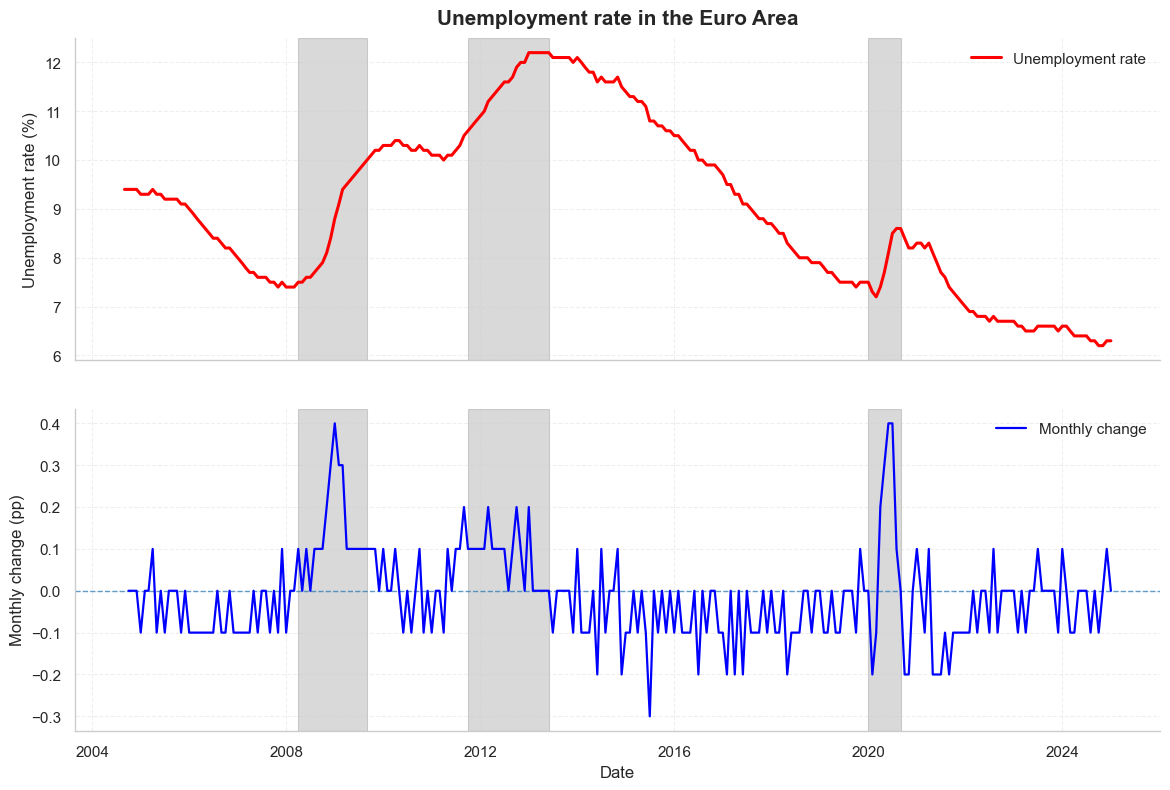

In [9]:
# ============================================================================
# 1/ We plot the unemployment rate in level and in difference
# ============================================================================
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True,
    gridspec_kw={"hspace": 0.15}
)

# Level
ax1.plot(
    data.index, data["UNETOT_EA"],
    linewidth=2.2, color="red", zorder=3,
    label="Unemployment rate"
)
ax1.set_ylabel("Unemployment rate (%)", fontsize=12)
ax1.set_title(
    "Unemployment rate in the Euro Area",
    fontsize=15, fontweight="bold", pad=10
)
ax1.legend(frameon=False, fontsize=11)

# Variation
ax2.plot(
    df_final.index, df_final["UNETOT_EA"],
    linewidth=1.6, color="blue", zorder=3,
    label="Monthly change"
)
ax2.axhline(0, linestyle="--", linewidth=1, alpha=0.7)
ax2.set_ylabel("Monthly change (pp)", fontsize=12)
ax2.set_xlabel("Date", fontsize=12)
ax2.legend(frameon=False, fontsize=11)

for ax in (ax1, ax2):
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.tick_params(labelsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Shaded areas = CEPR-dated recessions
rec = cepr_m["recession_cepr"]

in_rec = rec.eq(1)
starts = rec.index[in_rec & ~in_rec.shift(1, fill_value=False)]
ends   = rec.index[in_rec & ~in_rec.shift(-1, fill_value=False)]

for s, e in zip(starts, ends):
    ax1.axvspan(s, e, color="black", alpha=0.15, zorder=0)
    ax2.axvspan(s, e, color="black", alpha=0.15, zorder=0)

plt.tight_layout()
plt.savefig("images/unemployment_ea_level_and_change.png", dpi=300, bbox_inches="tight")
plt.show()

As expected, unemployment in the Euro area rise sharply when recessions occur. 

We now check missing values pattern.

Total missing values: 44
Columns with missing values: 16


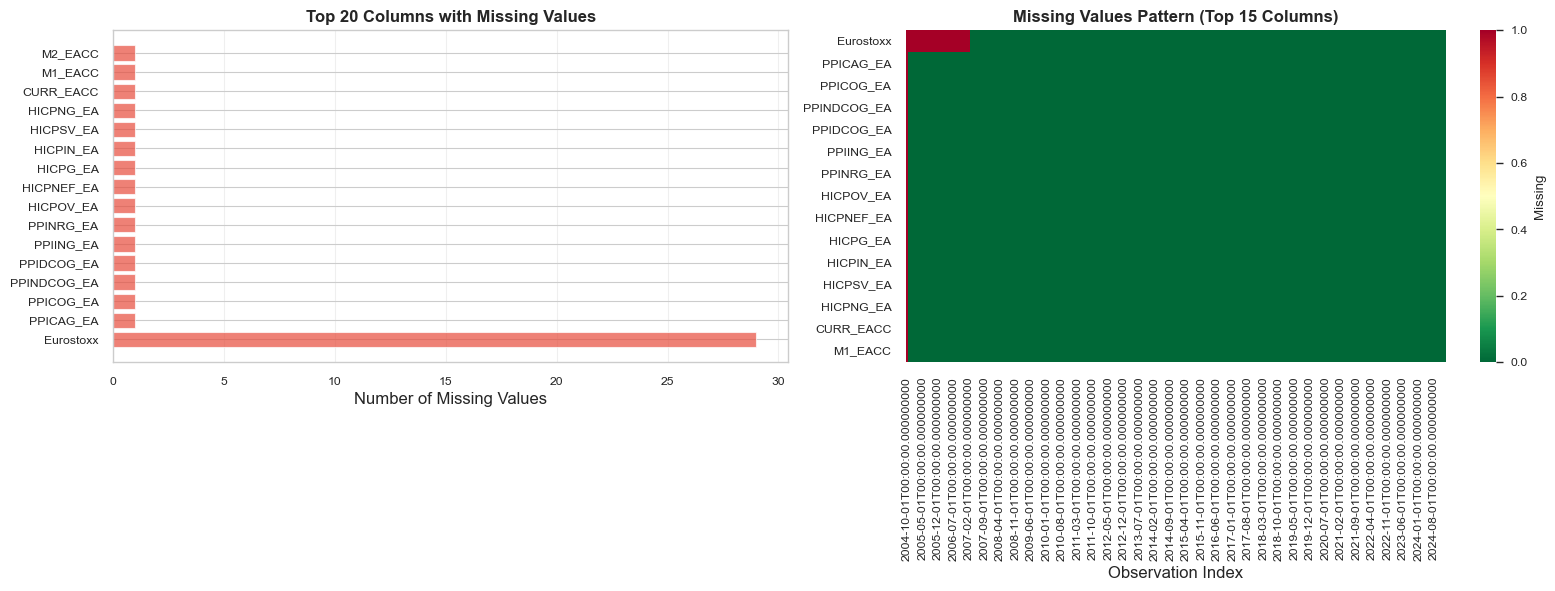

In [10]:
# Calculate missing values
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print(f"Total missing values: {missing.sum()}")
print(f"Columns with missing values: {len(missing_df)}")

# Visualize missing values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of missing values
top_missing = missing_df.head(20)
ax1.barh(range(len(top_missing)), top_missing['Missing_Count'], color='#e74c3c', alpha=0.7)
ax1.set_yticks(range(len(top_missing)))
ax1.set_yticklabels(top_missing['Column'])
ax1.set_xlabel('Number of Missing Values', fontsize=12)
ax1.set_title('Top 20 Columns with Missing Values', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Heatmap of missing values pattern
cols_with_missing = missing_df['Column'].head(15).tolist()
missing_pattern = df_final[cols_with_missing].isnull().astype(int)
sns.heatmap(missing_pattern.T, cmap='RdYlGn_r', cbar_kws={'label': 'Missing'}, ax=ax2, yticklabels=True)
ax2.set_xlabel('Observation Index', fontsize=12)
ax2.set_title('Missing Values Pattern (Top 15 Columns)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("images/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

There are not a lot of missing values, and they are concentrated at the beginning of the dataset. We now analyze potential outlier problem using standard interquartile range method on a rolling basis.

Outliers detected: 6
Outliers during CEPR recessions : 4
Outliers outside recessions    : 2


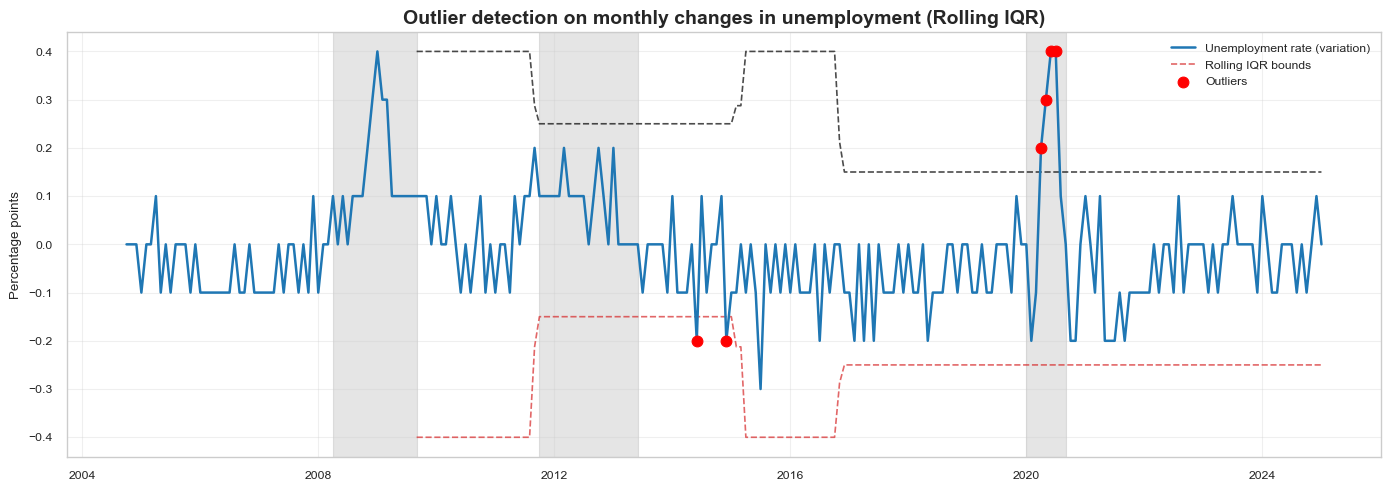

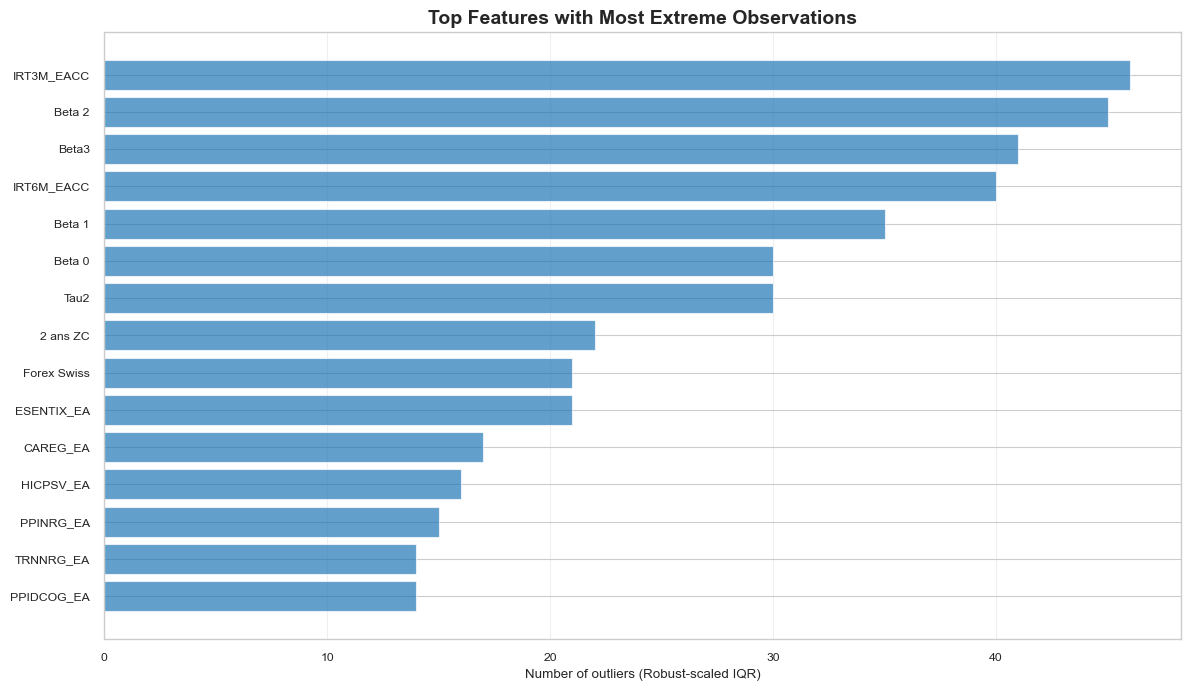

In [11]:
u_diff = df_final["UNETOT_EA"].dropna()
# ============================================================================
# 1/ We study outliers in the target variable
# ============================================================================

# Rolling IQR
window = 60  # 5 years
q1 = u_diff.rolling(window).quantile(0.25)
q3 = u_diff.rolling(window).quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = (u_diff < lower) | (u_diff > upper)
print("Outliers detected:", outliers.sum())
# We distinguish for "recession outliers" VS "expansion outliers"
rec = cepr_m["recession_cepr"].reindex(u_diff.index).fillna(0).astype(int)
outliers_rec = outliers & (rec == 1)
outliers_exp = outliers & (rec == 0)
print("Outliers during CEPR recessions :", outliers_rec.sum())
print("Outliers outside recessions    :", outliers_exp.sum())

# We plot IQR analysis
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(u_diff.index, u_diff, linewidth=1.8, label="Unemployment rate (variation)", zorder=3)
ax.plot(lower.index, lower, linestyle="--", alpha=0.7, label="Rolling IQR bounds")
ax.plot(upper.index, upper, linestyle="--", alpha=0.7)
ax.scatter(
    u_diff.index[outliers],
    u_diff[outliers],
    color="red", s=60, zorder=5, label="Outliers"
)
# CEPR recession shading
in_rec = rec.eq(1)
starts = u_diff.index[in_rec & ~in_rec.shift(1, fill_value=False)]
ends   = u_diff.index[in_rec & ~in_rec.shift(-1, fill_value=False)]
for s, e in zip(starts, ends):
    ax.axvspan(s, e, color="grey", alpha=0.2, zorder=0)
ax.set_title(
    "Outlier detection on monthly changes in unemployment (Rolling IQR)",
    fontsize=14, fontweight="bold"
)
ax.set_ylabel("Percentage points")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/outliers_unemployment.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================================
# 2/ We study outliers in the features
# ============================================================================
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()


scaler = RobustScaler()
X = pd.DataFrame(
    scaler.fit_transform(df_final[numeric_cols]),
    index=df_final.index,
    columns=numeric_cols
)
outlier_counts = {}
for col in X.columns:
    s = X[col].dropna()
    if len(s) > 50:
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_counts[col] = ((s < lower) | (s > upper)).sum()
outlier_df = (
    pd.DataFrame.from_dict(outlier_counts, orient="index", columns=["Outlier_Count"])
      .sort_values("Outlier_Count", ascending=False)
)
outlier_df.head(10)
fig, ax = plt.subplots(figsize=(12, 7))
top = outlier_df.head(15)
ax.barh(top.index, top["Outlier_Count"], alpha=0.7)
ax.invert_yaxis()
ax.set_xlabel("Number of outliers (Robust-scaled IQR)")
ax.set_title(
    "Top Features with Most Extreme Observations",
    fontsize=14, fontweight="bold"
)
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("images/outliers_features.png", dpi=300, bbox_inches="tight")
plt.show()


Extreme observations are predominantly concentrated during CEPR-dated recessionary episodes and coincide with periods of heightened macroeconomic and financial stress. They therefore reflect genuine economic shocks rather than measurement errors. The clustering of extreme values in short-term interest rates, yield curve factors, and exchange rates highlights the central role of financial markets and monetary policy in the propagation of macroeconomic stress. Rather than representing aberrant observations, these outliers are closely tied to economic history and are therefore preserved in the dataset to avoid eliminating economically meaningful crisis dynamics. 

We now analyze correlations between our target and our features.

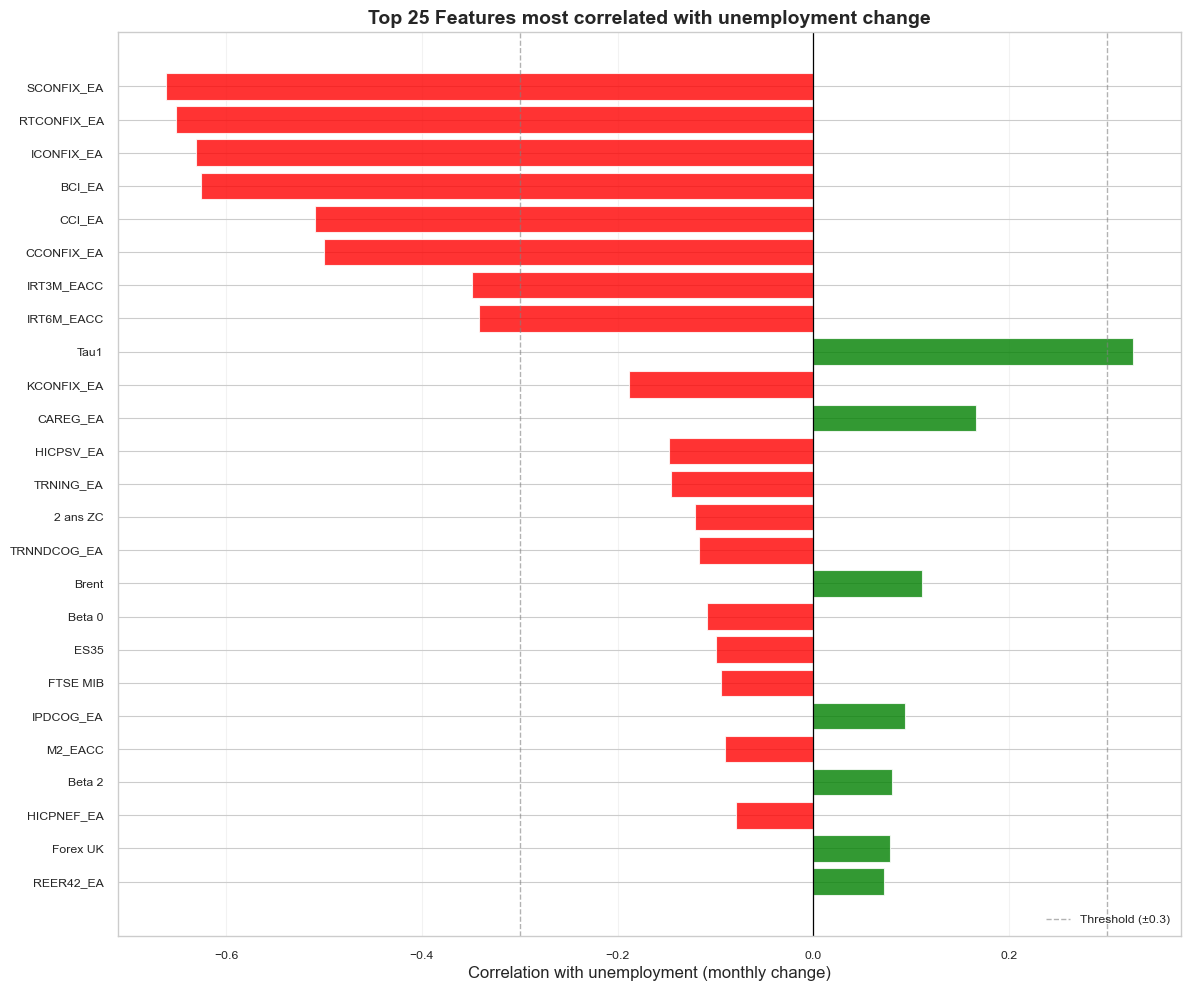


Features with |correlation| >= 0.3: 9


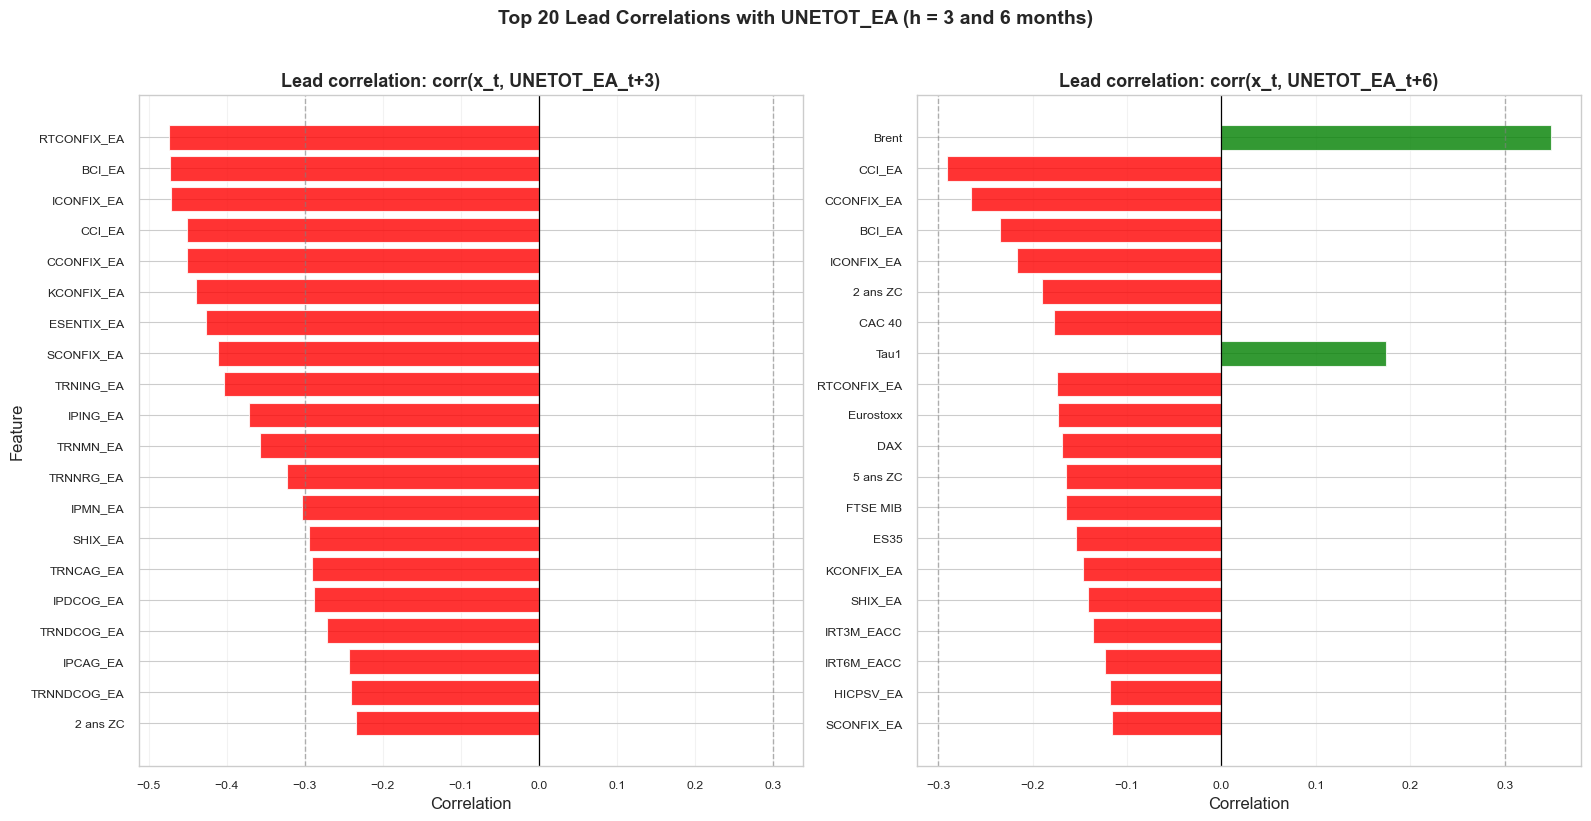

In [12]:
# ============================================================================
# 1/ Contemporaneous correlations
# ============================================================================
feature_cols = [col for col in df_final.columns if col != "UNETOT_EA"]
correlations = {}

for col in feature_cols:
    valid_mask = df_final[col].notna() & df_final["UNETOT_EA"].notna()
    if valid_mask.sum() > 10:
        correlations[col] = df_final.loc[valid_mask, col].corr(df_final.loc[valid_mask, "UNETOT_EA"])

corr_df = (
    pd.DataFrame({"Feature": list(correlations.keys()),
                  "Correlation": list(correlations.values())})
      .sort_values("Correlation", key=lambda s: s.abs(), ascending=False)
)

# We plot the top 25 contemporaneous correlations
threshold = 0.3
top_k = 25
top_corr = corr_df.head(top_k).copy()

fig, ax = plt.subplots(figsize=(12, 10))

colors = np.where(top_corr["Correlation"] >= 0, "green", "red")
ax.barh(np.arange(len(top_corr)), top_corr["Correlation"], color=colors, alpha=0.8)

ax.set_yticks(np.arange(len(top_corr)))
ax.set_yticklabels(top_corr["Feature"])
ax.invert_yaxis()

ax.set_xlabel("Correlation with unemployment (monthly change)", fontsize=12)
ax.set_title(f"Top {top_k} Features most correlated with unemployment change", fontsize=14, fontweight="bold")

ax.axvline(0, color="black", linewidth=0.9)
ax.axvline(threshold, color="gray", linestyle="--", linewidth=1, alpha=0.6, label=f"Threshold (±{threshold})")
ax.axvline(-threshold, color="gray", linestyle="--", linewidth=1, alpha=0.6)

ax.grid(True, alpha=0.25, axis="x")
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

selected = corr_df[corr_df["Correlation"].abs() >= threshold]
print(f"\nFeatures with |correlation| >= {threshold}: {len(selected)}")


# ============================================================================
# 2/ Lead correlation (with 3m-ahead and 6m-ahead unemployment)
# ============================================================================
target_col = "UNETOT_EA"
horizons = [3, 6]
top_n = 20
threshold = 0.3

if target_col not in df_final.columns:
    raise ValueError(
        f"'{target_col}' not found in df_final columns.\n"
        f"Available columns (first 30): {list(df_final.columns)[:30]}"
    )

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

for ax, h in zip(axes, horizons):
    corrs_h = lead_corr(df_final, target=target_col, h=h)
    if isinstance(corrs_h, pd.Series):
        top_h = corrs_h.dropna().abs().sort_values(ascending=False).head(top_n).index
        vals = corrs_h.loc[top_h]
        feats = vals.index.astype(str)
        corrs_vals = vals.values
    else:
        dfh = corrs_h.copy()
        if "Feature" not in dfh.columns:
            dfh = dfh.reset_index().rename(columns={"index": "Feature"})
        if "Correlation" not in dfh.columns:
            for alt in ["Corr", "corr", "correlation"]:
                if alt in dfh.columns:
                    dfh = dfh.rename(columns={alt: "Correlation"})
                    break
        dfh = dfh.dropna(subset=["Feature", "Correlation"])
        dfh = dfh.sort_values("Correlation", key=lambda s: s.abs(), ascending=False).head(top_n)
        feats = dfh["Feature"].astype(str).values
        corrs_vals = dfh["Correlation"].values

    colors = ["green" if x > 0 else "red" for x in corrs_vals]
    ax.barh(range(len(feats)), corrs_vals, color=colors, alpha=0.8)

    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats)
    ax.invert_yaxis()

    ax.axvline(0, color="black", linewidth=0.9)
    ax.axvline(threshold, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.axvline(-threshold, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    ax.grid(True, alpha=0.25, axis="x")
    ax.set_title(f"Lead correlation: corr(x_t, {target_col}_t+{h})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Correlation", fontsize=12)

axes[0].set_ylabel("Feature", fontsize=12)

fig.suptitle(
    f"Top {top_n} Lead Correlations with {target_col} (h = {horizons[0]} and {horizons[1]} months)",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()


Survey-based confidence indicators exhibit the strongest negative correlations, both contemporaneously and at short horizons. At longer horizons, financial variables such as oil prices, yield curve factors, and interest rates gain explanatory power, consistent with slower transmission channels through prices and financial conditions. Overall, these results emphasize the central role of expectations and financial conditions in driving short- to medium-term labor market fluctuations.

## 4. Factor-based indicator

We construct a factor-based economic and financial conditions indicator following a four-step procedure designed to avoid look-ahead bias:

1. **Rolling missing data imputation**: Within each rolling window of 36 months, we handle missing values using an Expectation-Maximization PCA (EM-PCA) algorithm;

2. **Rolling factor extraction**: For each window, we apply Principal Component Analysis to the imputed dataset to extract common factors summarizing the co-movements across macroeconomic and financial variables. The optimal number of factors is selected using the Bai and Ng (2002) IC2 information criterion, allowing the dimensionality to vary over time;

3. **Rolling regression**: We estimate a rolling linear regression of the monthly change in the unemployment rate on the window-specific extracted factors:
$$
\Delta u_t = \alpha_t + \beta'_t F_t + \varepsilon_t
$$
where both the factors $F_t$ and the regression coefficients $(\alpha_t, \beta_t)$ are estimated over a rolling window of 36 months. This fully rolling specification allows both the underlying economic structure and its relationship with unemployment to evolve over time;

4. **Indicator construction**: The composite indicator is defined as the negative fitted component of unemployment changes: $I_t = -\hat{\beta}'_t F_t$. The negative sign ensures that higher values correspond to more favorable economic conditions (declining unemployment). The series is then rescaled to follow a PMI-like normalization with mean 50 and standard deviation 10. Values above 50 signal economic expansion, while values below 50 indicate contraction.


This is the methodolody used to construct the indicator. However, we propose first to apply EM-PCA on the entire dataset to analyze the loadings.

We first create some helper functions.

In [ ]:
# ============================================================================
# Data
# ============================================================================
y = df_final["UNETOT_EA"]
X = df_final.drop(columns=["UNETOT_EA"])

# ============================================================
# Helper functions (PMI-like indicator + plotting)
# ============================================================
def indicator_pmi(raw_indic: pd.Series, y_aligned: pd.Series) -> pd.DataFrame:
    """Build PMI-like indicator (mean=50, std=10) and return a DataFrame with aligned y."""
    mean_ref: float = raw_indic.mean()
    std_ref: float = raw_indic.std(ddof=1)

    indicator_scaled = 50 + 10 * (raw_indic - mean_ref) / std_ref
    indicator_scaled.name = "Indicator"

    df_indicator = pd.DataFrame(
        {
            "Indicator": indicator_scaled,
            "Unemployment_change": y_aligned.reindex(indicator_scaled.index),
        },
        index=indicator_scaled.index,
    )
    return df_indicator


def plot_index(df_indicator: pd.DataFrame, window: int, starts, ends,
               title: str = "Economic Indicator - Euro Area (Rolling Regression)") -> None:
    """Plot PMI-like indicator with recession shading defined by starts/ends."""
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(
        df_indicator.index,
        df_indicator["Indicator"],
        linewidth=2,
        label=f"Indicator (Rolling OLS {window}m)",
        color="darkblue",
    )
    ax.axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.5)

    ax.fill_between(
        df_indicator.index,
        50,
        df_indicator["Indicator"],
        where=(df_indicator["Indicator"] > 50),
        alpha=0.2,
        color="green",
        label="Expansion (>50)",
    )
    ax.fill_between(
        df_indicator.index,
        50,
        df_indicator["Indicator"],
        where=(df_indicator["Indicator"] < 50),
        alpha=0.2,
        color="red",
        label="Contraction (<50)",
    )

    # Recession shading (starts/ends defined elsewhere)
    for s, e in zip(starts, ends):
        ax.axvspan(s, e, color="grey", alpha=0.2, zorder=0)

    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Indicator Value", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(loc="upper left", fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Now, we proceed to the principal component estimation **on the entire dataset**.

In [14]:
# ============================================================================
# GLOBAL FACTORS
# ============================================================================
empca_global = EM_PCA(
    kmax=10,
    criterion="IC2",
    demean=2,
    max_iter=50,
    tol=1e-6,
    fallback_n_factors=3,
    verbose=False,
)
result_global = empca_global.fit(X)
factors = result_global.factors            
loadings = result_global.loadings          
imputed_data = result_global.imputed_data  
r2_by_var = result_global.r2_by_variable   

# Analysis
print("\n" + "=" * 70)
print("FACTOR ANALYSIS")
print("=" * 70)
print("Factors extracted:")
print(f"  - Number of factors : {result_global.n_factors}")
print(f"  - Total variance explained : {result_global.variance_explained:.2%}")


FACTOR ANALYSIS
Factors extracted:
  - Number of factors : 10
  - Total variance explained : 68.21%


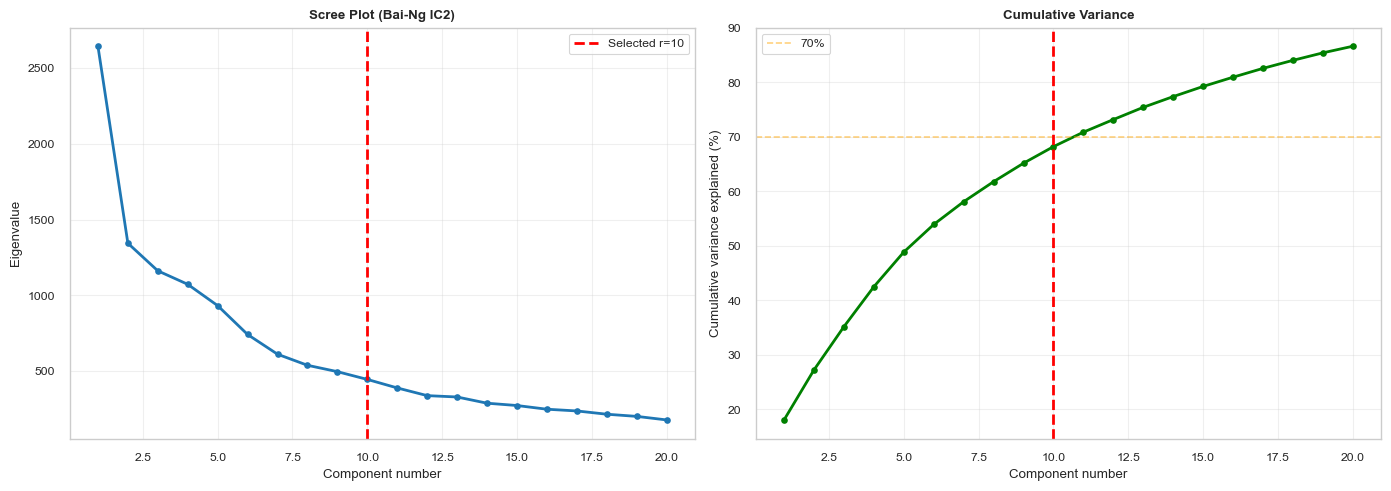

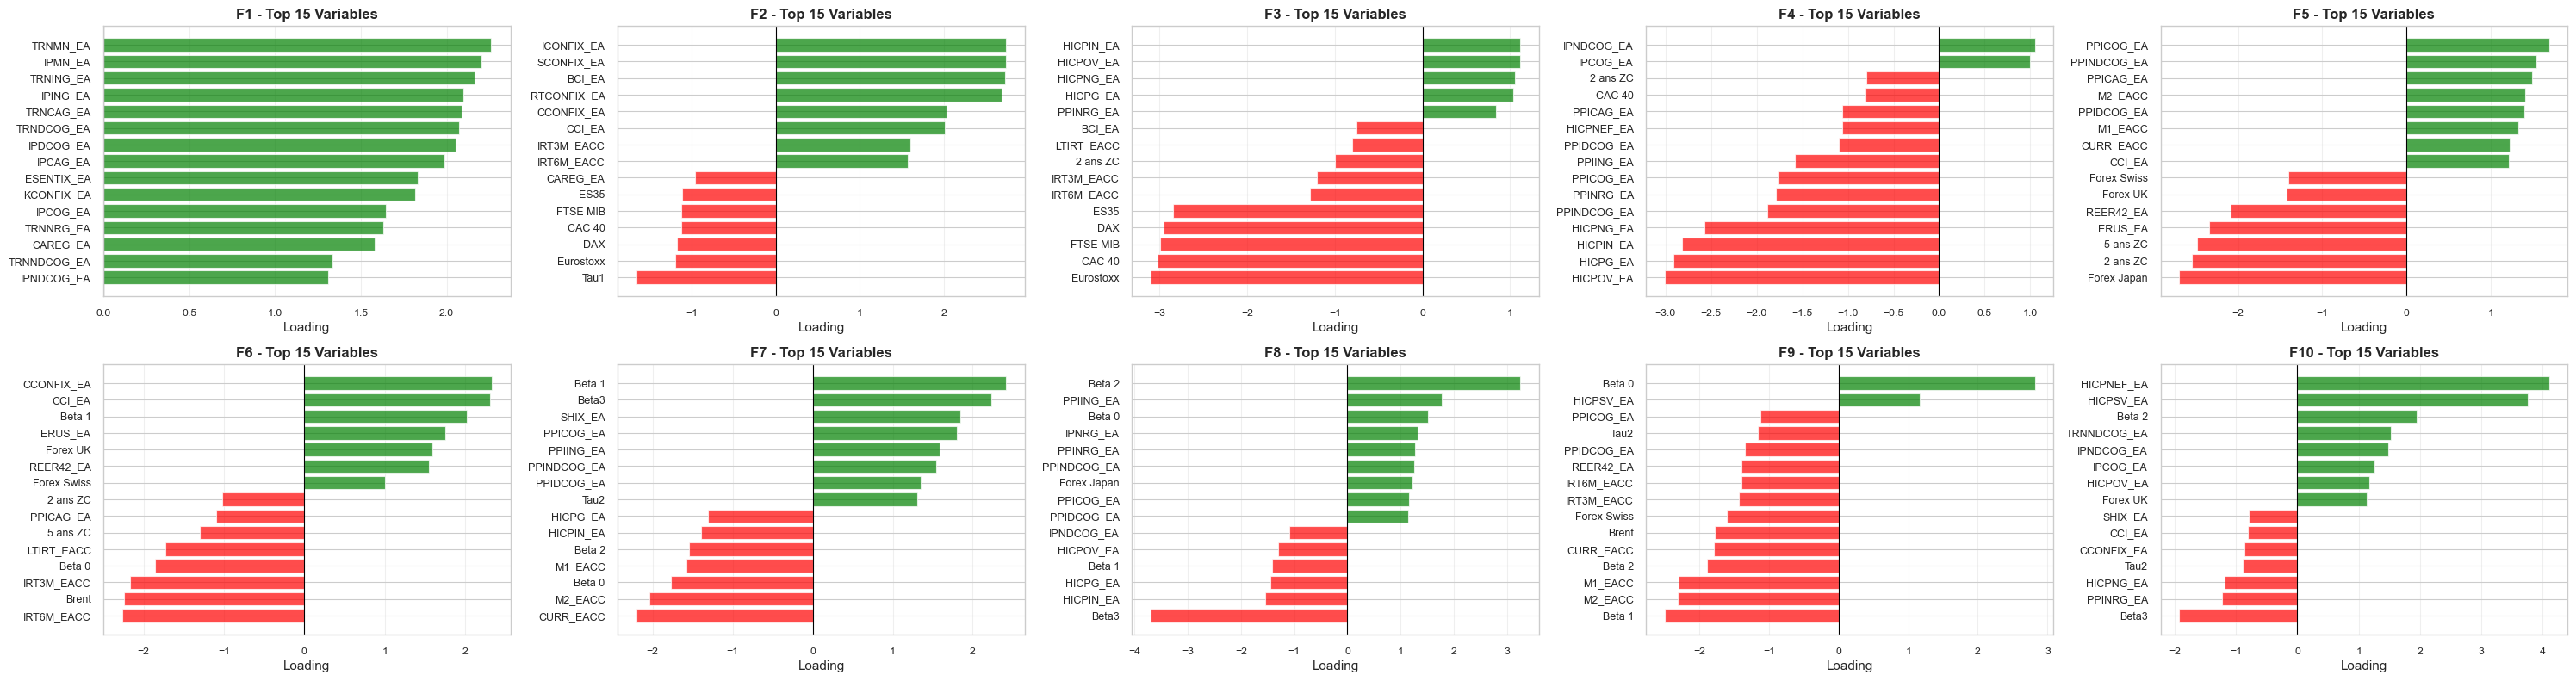

In [17]:
# ==================== VISUALISATIONS ====================
# Scree plot (eigenvalues) + cumulative variance
eigenvalues = result_global.eigenvalues
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, min(20, len(eigenvalues)) + 1), eigenvalues[:20], "o-", linewidth=2)
ax1.axvline(result_global.n_factors, color="r", linestyle="--", linewidth=2, label=f"Selected r={result_global.n_factors}")
ax1.set_xlabel("Component number")
ax1.set_ylabel("Eigenvalue")
ax1.set_title("Scree Plot (Bai-Ng IC2)", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

cumvar = np.cumsum(eigenvalues) / np.sum(eigenvalues) * 100
ax2.plot(range(1, min(20, len(cumvar)) + 1), cumvar[:20], "o-", linewidth=2, color="green")
ax2.axhline(70, color="orange", linestyle="--", alpha=0.5, label="70%")
ax2.axvline(result_global.n_factors, color="r", linestyle="--", linewidth=2)
ax2.set_xlabel("Component number")
ax2.set_ylabel("Cumulative variance explained (%)")
ax2.set_title("Cumulative Variance", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Loadings
n_factors: int = result_global.n_factors
n_cols: int = 5
n_rows: int = math.ceil(n_factors / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4 * n_rows),
    squeeze=False
)

for i in range(n_factors):
    row, col = divmod(i, n_cols)
    ax = axes[row, col]

    factor_name = f"F{i+1}"
    top_vars = loadings[factor_name].abs().nlargest(15)
    top_loadings = loadings.loc[top_vars.index, factor_name].sort_values()

    colors = ["green" if x > 0 else "red" for x in top_loadings]
    ax.barh(range(len(top_loadings)), top_loadings.values,
            color=colors, alpha=0.7)

    ax.set_yticks(range(len(top_loadings)))
    ax.set_yticklabels(top_loadings.index, fontsize=9)
    ax.set_xlabel("Loading", fontsize=11)
    ax.set_title(f"{factor_name} - Top 15 Variables",
                 fontsize=12, fontweight="bold")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(True, alpha=0.3, axis="x")

for j in range(n_factors, n_rows * n_cols):
    row, col = divmod(j, n_cols)
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

The ten retained factors explain close to 70% of the variance, a standard magnitude for macro-financial studies. A detailed discussion of the corresponding loadings is presented in the associated report.

We now proceed to the estimation of the indicator itself, following the aforementioned procedure. First, the model is estimated on the full sample in order to construct the indicator. Second, the sample is split into training and test periods to compute out-of-sample error metrics, which will serve as a benchmark for comparison with alternative machine learning approaches.

Train: 2004-10-01 00:00:00 to 2021-01-01 00:00:00
Test:  2021-02-01 00:00:00 to 2025-01-01 00:00:00
Test RMSE (walk-forward OOS): 0.0772
Test MAE  (walk-forward OOS): 0.0636


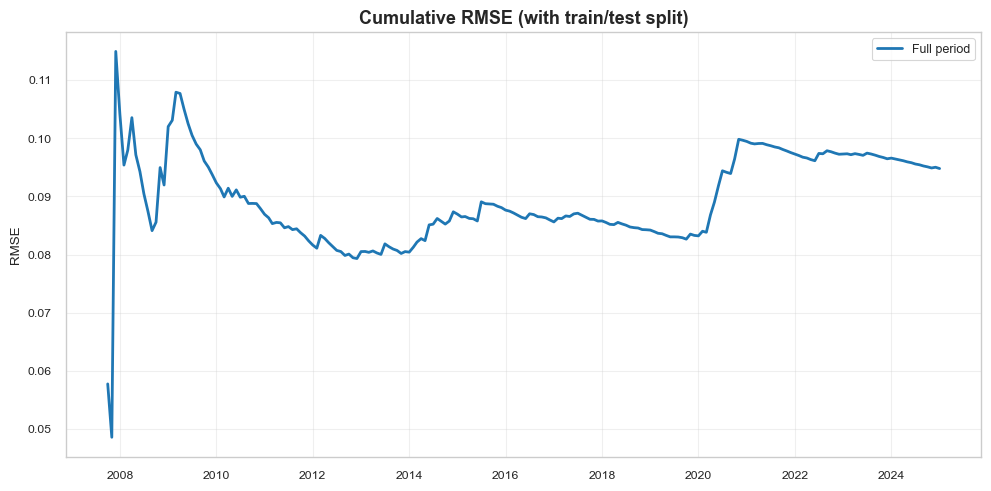

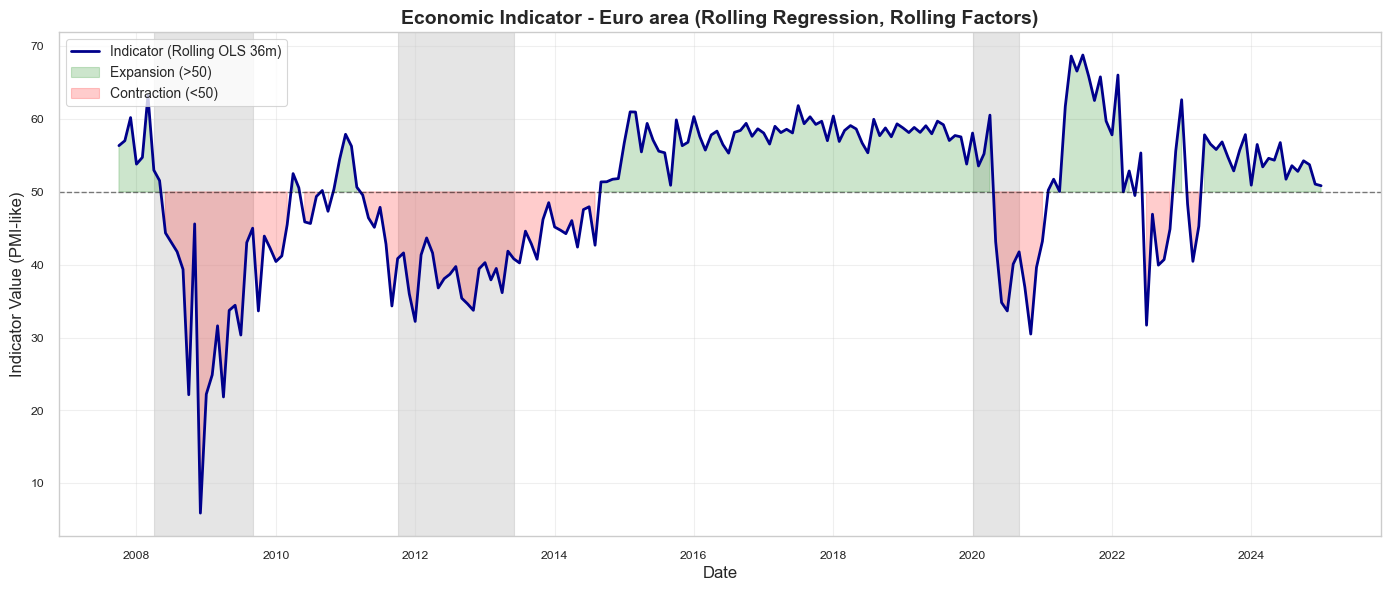

<Figure size 640x440 with 0 Axes>

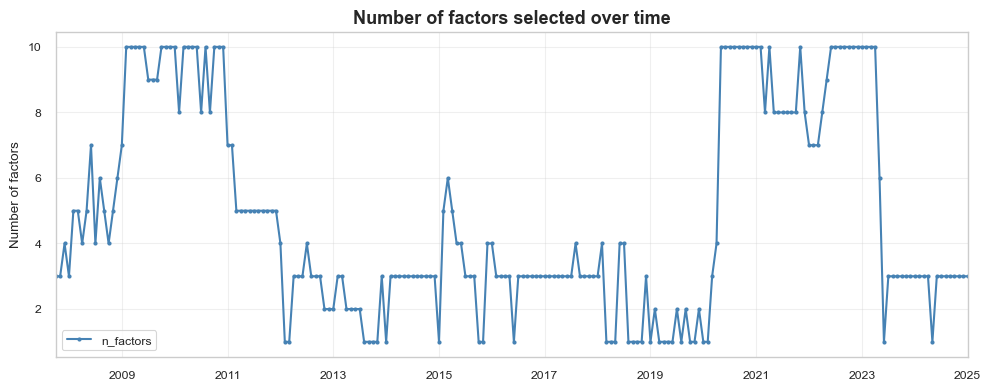

In [ ]:
# =============================================================================
# We split data: 80% = train, 20% = test
# =============================================================================
TEST_SIZE: float = 0.20
n_total: int = len(y)
n_test: int = int(n_total * TEST_SIZE)
n_train: int = n_total - n_test

y_train = y.iloc[:n_train]
X_train = X.iloc[:n_train]
y_test = y.iloc[n_train:]
X_test = X.iloc[n_train:]

print(f"Train: {y_train.index[0]} to {y_train.index[-1]}")
print(f"Test:  {y_test.index[0]} to {y_test.index[-1]}")

# =============================================================================
# Fit on training data only for future OOS metrics
# =============================================================================
window: int = 36
roll_reg_train = RollingRegression(
    y=y_train,
    X=X_train,
    window=window,
    extract_factors=True,
    empca_params={
        "kmax": 10,
        "criterion": "IC2",
        "n_factors": None,
        "demean": 2,
        "max_iter": 50,
        "tol": 1e-6,
        "verbose": False,
    },
)
result_train = roll_reg_train.fit()
y_true_train = y_train.loc[result_train.fitted.index]
errors_train = y_true_train - result_train.fitted

# =============================================================================
# Fit on full data to construct the indicator for the whole period
# =============================================================================

roll_reg_full = RollingRegression(
    y=y,
    X=X,
    window=window,
    extract_factors=True,
    empca_params={
        "kmax": 10,
        "criterion": "IC2",
        "n_factors": None,
        "demean": 2,
        "max_iter": 50,
        "tol": 1e-6,
        "verbose": False,
    },
)
result_full = roll_reg_full.fit()

# =============================================================================
# OOS performance
# =============================================================================
# OOS predictions over test from the rolling procedure 
y_pred_test = result_full.fitted.reindex(y_test.index).dropna()
y_true_test = y_test.reindex(y_pred_test.index)

errors_test = y_true_test - y_pred_test
rmse_test = float(np.sqrt((errors_test ** 2).mean()))
mae_test = float(errors_test.abs().mean())

print(f"Test RMSE (OOS): {rmse_test:.4f}")
print(f"Test MAE  (OOS): {mae_test:.4f}")

# =============================================================================
# Construction of the PMI-like indicator 
# =============================================================================

indicator_raw_full = -result_full.fitted
y_aligned_full = y.loc[indicator_raw_full.index]
df_indicator_full = indicator_pmi(indicator_raw_full, y_aligned_full)


# =============================================================================
# Visualisations
# =============================================================================
# FIGURE 1: Cumulative RMSE (full period)
errors_full = y.loc[result_full.fitted.index] - result_full.fitted
rmse_cum_full = errors_full.expanding().apply(lambda x: np.sqrt((x**2).mean()))
rmse_cum_full.name = "Cumulative RMSE"

fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(rmse_cum_full.index, rmse_cum_full.values, linewidth=2, label="Full period")
ax1.set_title("Cumulative RMSE (with train/test split)", fontsize=13, fontweight="bold")
ax1.set_ylabel("RMSE")
ax1.legend(loc="best", fontsize=9)
ax1.grid(alpha=0.3)

fig1.tight_layout()
fig1.savefig("images/factor_cumulative_rmse.png", dpi=150, bbox_inches="tight")
plt.show()


# FIGURE 2: Indicator 

plot_index(
    df_indicator=df_indicator_full,
    window=window,
    starts=starts,
    ends=ends,
    title="Economic Indicator - Euro area (Rolling Regression, Rolling Factors)",
)

plt.gcf().savefig("images/factor_pmi_like_indicator.png", dpi=150, bbox_inches="tight")
plt.show()

# FIGURE 3: Number of factors over time

fig3, ax3 = plt.subplots(figsize=(10, 4))
if roll_reg_full.factor_info_ is not None:
    n_factors_series = roll_reg_full.factor_info_["n_factors"]
    n_factors_series.plot(ax=ax3, marker="o", linewidth=1.5, markersize=3, color="steelblue")
    ax3.set_title("Number of factors selected over time", fontsize=13, fontweight="bold")
    ax3.set_ylabel("Number of factors")
    ax3.legend(loc="best")
    ax3.grid(alpha=0.3)
else:
    ax3.text(0.5, 0.5, "Fixed number of factors", ha="center", va="center", transform=ax3.transAxes)
    ax3.axis("off")

fig3.tight_layout()
fig3.savefig("images/factor_number_of_factors.png", dpi=150, bbox_inches="tight")
plt.show()

## Machine Learning methods

We now turn to machine learning methods. We focus on supervised learning approaches, where the target variable is the monthly change in the unemployment rate and the feature set consists of macroeconomic and financial variables, potentially augmented with lagged values. We use expanding windows: intuitively and conceptually, we would rather consider rolling windows, however that would mean using ML techniques on really small datasets each time. 

We begin by comparing a family of penalized linear regression models, namely:
- a baseline LASSO;
- a baseline Ridge regression;
- a baseline Elastic Net;
- an Adaptive LASSO;
- a Group LASSO, where groups are defined for macroeconomic variables according to the EA-MD classifications (exchange rates, interest rates, industrial production and turnover, prices, confidence indicators, monetary aggregates, and other variables).

As a first step, we evaluate the out-of-sample performance of these models using default hyperparameters, without any fine-tuning. Based on these initial results, we then select the most promising specifications and apply time-series-robust cross-validation procedures to tune the hyperparameters in a second stage.

COMPARISON: LASSO, RIDGE, ELASTIC NET, ADAPTIVE LASSO, GROUPED LASSO
Group sizes: exchange_rates=2, interest_rates=3, industrial_production_turnover=13, prices=12, confidence_indicators=8, monetary_aggregates=3, other=2, financial_variables=17

Window type: EXPANDING
Initial window: 36 months

Estimating LASSO

Estimating RIDGE

Estimating ELASTIC NET
  Final RMSE: 0.0883
  Selected variables (mean): 17.3

Estimating ADAPTIVE LASSO
  Effective alpha: 0.001

Estimating GROUPED LASSO


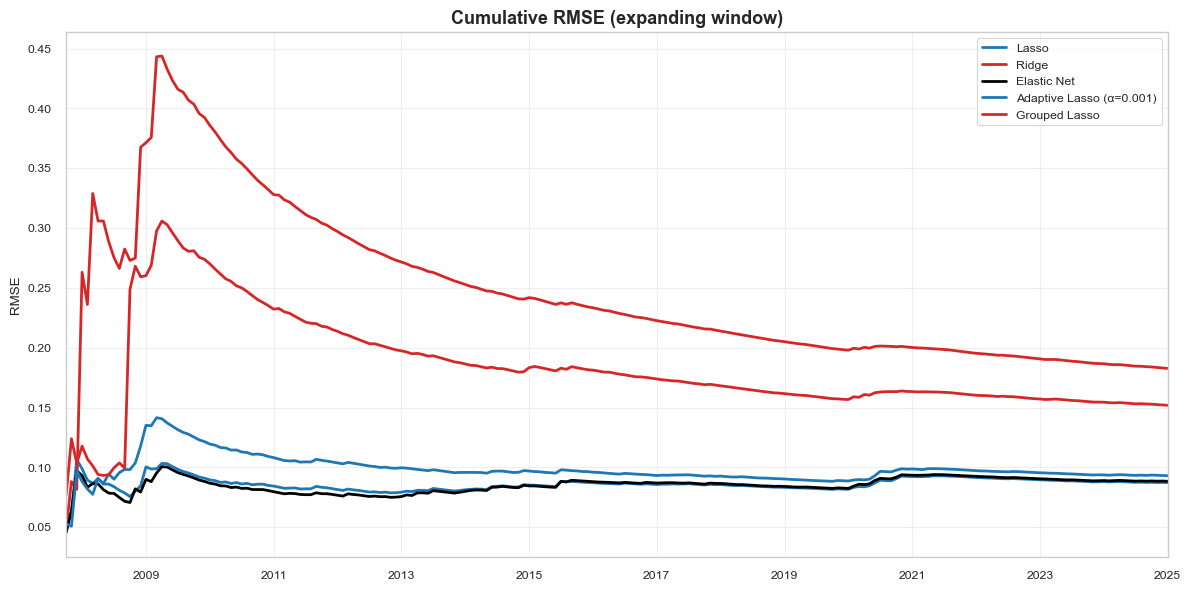

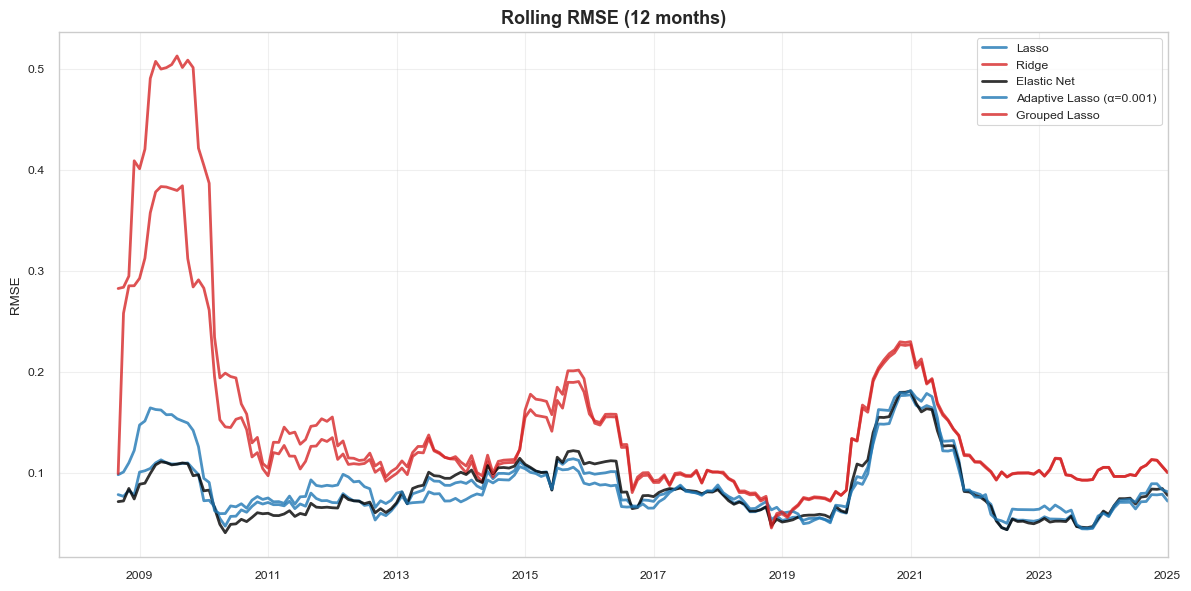

                   Model  Final RMSE    MAE  Std Error
                   Lasso      0.0872 0.0676     0.0872
                   Ridge      0.1827 0.1193     0.1831
             Elastic Net      0.0883 0.0677     0.0882
Adaptive Lasso (α=0.001)      0.0930 0.0726     0.0927
           Grouped Lasso      0.1518 0.1069     0.1522

Best model: Lasso (Final RMSE = 0.0872)


In [ ]:
print("="*70)
print("COMPARISON: LASSO, RIDGE, ELASTIC NET, ADAPTIVE LASSO, GROUPED LASSO")
print("="*70)

# Detailed economic groups
groups = {
    "exchange_rates": ["REER42_EA", "ERUS_EA"],
    "interest_rates": ["IRT3M_EACC", "IRT6M_EACC", "LTIRT_EACC"],
    "industrial_production_turnover": [
        "IPMN_EA", "IPCAG_EA", "IPCOG_EA", "IPDCOG_EA",
        "IPNDCOG_EA", "IPING_EA", "IPNRG_EA",
        "TRNMN_EA", "TRNCAG_EA", "TRNDCOG_EA",
        "TRNNDCOG_EA", "TRNING_EA", "TRNNRG_EA"
    ],
    "prices": [
        "PPICAG_EA", "PPICOG_EA", "PPINDCOG_EA", "PPIDCOG_EA",
        "PPIING_EA", "PPINRG_EA",
        "HICPOV_EA", "HICPNEF_EA", "HICPG_EA",
        "HICPIN_EA", "HICPSV_EA", "HICPNG_EA"
    ],
    "confidence_indicators": [
        "ICONFIX_EA", "CCONFIX_EA", "KCONFIX_EA",
        "RTCONFIX_EA", "SCONFIX_EA", 
        "ESENTIX_EA", "BCI_EA", "CCI_EA"
    ],
    "monetary_aggregates": ["M1_EACC", "M2_EACC", "CURR_EACC"],
    "other": ["SHIX_EA", "CAREG_EA"],
}
# We add financial variables
cols = list(X.columns)
split_idx = cols.index("Eurostoxx")
financial_vars = cols[split_idx:]
groups["financial_variables"] = financial_vars
print(f"Group sizes: {', '.join([f'{k}={len(v)}' for k, v in groups.items()])}")

# =============================================================================
# HYPERPARAMETERS
# =============================================================================
WINDOW = 36  # Initial training window size
WINDOW_TYPE = 'expanding'  
N_FACTORS_IMP = 10
RMSE_WINDOW = 12

# Model-specific alphas
alpha_lasso = 0.01
alpha_ridge = 0.01
alpha_en = 0.01
l1_ratio_en = 0.5

# Adaptive Lasso 
alpha_adapt = 0.001
gamma_adapt = 1.0
alpha_initial_adapt = 1.0

alpha_group = 0.01

# =============================================================================
# COMMON PARAMETERS 
# =============================================================================
common_params = {
    'window': WINDOW,
    'window_type': WINDOW_TYPE, 
    'imputation_method': 'em',
    'n_factors_imputation': N_FACTORS_IMP,
    'rmse_window': RMSE_WINDOW,
    'store_coefs': True,
    'verbose': False
}

# =============================================================================
# ESTIMATIONS
# =============================================================================

print(f"\nWindow type: {WINDOW_TYPE.upper()}")
print(f"Initial window: {WINDOW} months\n")

# 1/ LASSO 
print("Estimating LASSO")
lasso = RollingLasso(
    alpha=alpha_lasso,
    **common_params  
)
result_lasso = lasso.fit(y=y, X=X)

# 2/ RIDGE
print("\nEstimating RIDGE")
ridge = RollingRidge(
    alpha=alpha_ridge,
    **common_params
)
result_ridge = ridge.fit(y=y, X=X)

# 3/ ElasticNet
print("\nEstimating ELASTIC NET")
elasticnet = RollingElasticNet(
    alpha=alpha_en,
    l1_ratio=l1_ratio_en,
    **common_params
)
result_en = elasticnet.fit(y=y, X=X)

# 4/ ADAPTIVE LASSO
print("\nEstimating ADAPTIVE LASSO")
adapt = RollingAdaptiveLasso(
    alpha=alpha_adapt,
    gamma=gamma_adapt,
    initial_estimator='ridge',
    alpha_initial=alpha_initial_adapt,
    **common_params
)
result_adapt = adapt.fit(y=y, X=X)

# Auto-adjust if too aggressive
if result_adapt.n_nonzero_coefs.mean() < 0.5:
    print("Too aggressive (around 0 variables), lowering alpha and refitting...")
    alpha_adapt = alpha_adapt / 10.0
    adapt = RollingAdaptiveLasso(
        alpha=alpha_adapt,
        gamma=gamma_adapt,
        initial_estimator='ridge',
        alpha_initial=alpha_initial_adapt,
        **common_params
    )
    result_adapt = adapt.fit(y=y, X=X)
print(f"  Effective alpha: {alpha_adapt}")

# 5/ GROUPED LASSO
print("\nEstimating GROUPED LASSO")
group_lasso = RollingGroupLasso(
    alpha=alpha_group,
    groups=groups,
    **common_params
)
result_gl = group_lasso.fit(y=y, X=X)

# =============================================================================
# VISUALIZATIONS
# =============================================================================
# 1/ Cumulative RMSE
fig, ax = plt.subplots(figsize=(12, 6))
result_lasso.rmse_cum.plot(ax=ax, label="Lasso", linewidth=2)
result_ridge.rmse_cum.plot(ax=ax, label="Ridge", linewidth=2)
result_en.rmse_cum.plot(ax=ax, label="Elastic Net", linewidth=2)
result_adapt.rmse_cum.plot(ax=ax, label=f"Adaptive Lasso)", linewidth=2)
result_gl.rmse_cum.plot(ax=ax, label="Grouped Lasso", linewidth=2)

ax.set_title(f"Cumulative RMSE ({WINDOW_TYPE} window)", fontsize=13, fontweight="bold")
ax.set_ylabel("RMSE")
ax.legend(loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"images/comparison_cumulative_rmse_{WINDOW_TYPE}.png", dpi=150, bbox_inches="tight")
plt.show()

# 2/ ROLLING RMSE 
fig, ax = plt.subplots(figsize=(12, 6))

if result_lasso.rmse_roll is not None:
    result_lasso.rmse_roll.plot(ax=ax, label="Lasso", linewidth=2, alpha=0.8)
if result_ridge.rmse_roll is not None:
    result_ridge.rmse_roll.plot(ax=ax, label="Ridge", linewidth=2, alpha=0.8)
if result_en.rmse_roll is not None:
    result_en.rmse_roll.plot(ax=ax, label="Elastic Net", linewidth=2, alpha=0.8)
if result_adapt.rmse_roll is not None:
    result_adapt.rmse_roll.plot(ax=ax, label=f"Adaptive Lasso (α={alpha_adapt:g})", linewidth=2, alpha=0.8)
if result_gl.rmse_roll is not None:
    result_gl.rmse_roll.plot(ax=ax, label="Grouped Lasso", linewidth=2, alpha=0.8)

ax.set_title(f"Rolling RMSE ({RMSE_WINDOW} months)", fontsize=13, fontweight="bold")
ax.set_ylabel("RMSE")
ax.legend(loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"images/comparison_rolling_rmse_{WINDOW_TYPE}.png", dpi=150, bbox_inches="tight")
plt.show()


# 3/ Performance table 
comparison_df = pd.DataFrame({
    "Model": [
        "Lasso",
        "Ridge",
        "Elastic Net",
        f"Adaptive Lasso (α={alpha_adapt:g})",
        "Grouped Lasso",
    ],
    "Final RMSE": [
        float(result_lasso.rmse_cum.iloc[-1]),
        float(result_ridge.rmse_cum.iloc[-1]),
        float(result_en.rmse_cum.iloc[-1]),
        float(result_adapt.rmse_cum.iloc[-1]),
        float(result_gl.rmse_cum.iloc[-1]),
    ],
    "MAE": [
        float(result_lasso.err.abs().mean()),
        float(result_ridge.err.abs().mean()),
        float(result_en.err.abs().mean()),
        float(result_adapt.err.abs().mean()),
        float(result_gl.err.abs().mean()),
    ],
    "Std Error": [
        float(result_lasso.err.std()),
        float(result_ridge.err.std()),
        float(result_en.err.std()),
        float(result_adapt.err.std()),
        float(result_gl.err.std()),
    ],
})

print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_model_idx = comparison_df["Final RMSE"].idxmin()
best_model = comparison_df.loc[best_model_idx, "Model"]
best_rmse = comparison_df.loc[best_model_idx, "Final RMSE"]
print(f"\nBest model: {best_model} (Final RMSE = {best_rmse:.4f})")

Overall, LASSO and Elastic Net emerge as the most competitive approaches in their baseline specifications, while Grouped Lasso performs less favorably at this stage, suggesting that its effectiveness is highly sensitive to the choice of hyperparameters. The non-parsimonious Ridge regression is clearly dominated and appears as the weakest performer, highlighting the importance of penalizing model complexity in a high-dimensional macro-financial setting, as expected. Finally, during macro shocks, all models deteriorate, but clearly the variable selection helps in break periods. 

We now decide to fine-tune the hyperparameters of the most promising models (LASSO and Elastic Net), as well as Grouped Lasso, whose performance may substantially improve once appropriately calibrated. We pay great care to use time-series robust cross validation, ensuring that the test set always chronologically follows the training set.

HYPERPARAMETER TUNING

Train+Valid:  195 obs (2004-10 to 2020-12)
Test:          49 obs (2021-01 to 2025-01)

TUNING LASSO
  [1/8] Testing {'alpha': 0.005, 'n_lags': 3}...
CV RMSE: 0.0901 ± 0.0049
  [2/8] Testing {'alpha': 0.005, 'n_lags': 6}...
CV RMSE: 0.0949 ± 0.0072
  [3/8] Testing {'alpha': 0.01, 'n_lags': 3}...
CV RMSE: 0.0866 ± 0.0036
  [4/8] Testing {'alpha': 0.01, 'n_lags': 6}...
CV RMSE: 0.0886 ± 0.0045
  [5/8] Testing {'alpha': 0.02, 'n_lags': 3}...
CV RMSE: 0.0885 ± 0.0030
  [6/8] Testing {'alpha': 0.02, 'n_lags': 6}...
CV RMSE: 0.0880 ± 0.0037
  [7/8] Testing {'alpha': 0.05, 'n_lags': 3}...
CV RMSE: 0.1096 ± 0.0095
  [8/8] Testing {'alpha': 0.05, 'n_lags': 6}...
CV RMSE: 0.1089 ± 0.0092

BEST LASSO
  alpha = 0.0100, n_lags = 3
  CV RMSE = 0.0866 ± 0.0036
  Number of variables (mean) = 18.8

Full Results:
 alpha  n_lags  mean_cv_rmse  std_cv_rmse  mean_cv_mae  std_cv_mae  mean_nvars  std_nvars
0.0050       3        0.0901       0.0049       0.0741      0.0051     31.9945   

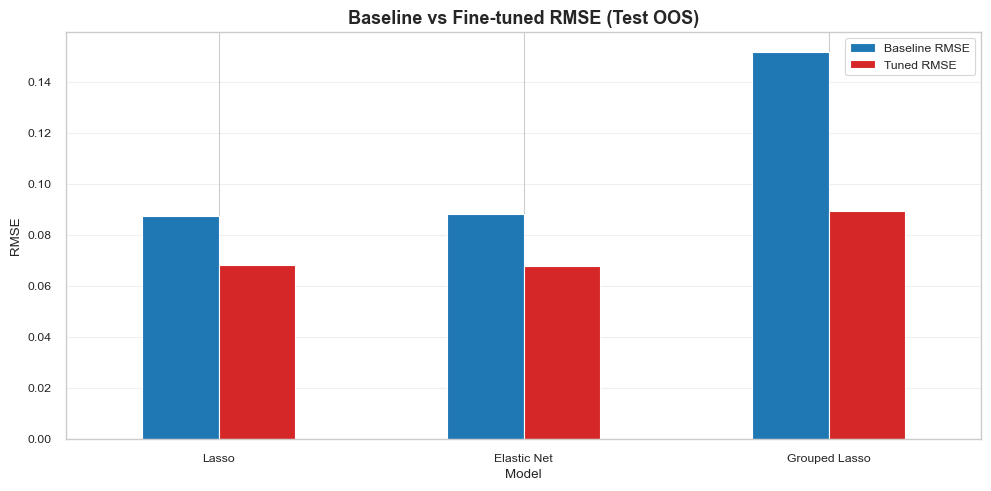


# Best parameters:
alpha_lasso = 0.0100, n_lags = 3
alpha_en = 0.0500, l1_ratio = 0.30, n_lags = 6
alpha_group = 0.5000, n_lags = 3


In [27]:
print("="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# =============================================================================
# DATA SPLIT
# =============================================================================

split_test = int(len(X) * 0.8)
X_trainval = X.iloc[:split_test]
y_trainval = y.iloc[:split_test]
X_test_final = X.iloc[split_test:]
y_test_final = y.iloc[split_test:]

print(f"\nTrain+Valid: {len(X_trainval):4d} obs ({X_trainval.index[0].strftime('%Y-%m')} to {X_trainval.index[-1].strftime('%Y-%m')})")
print(f"Test:        {len(X_test_final):4d} obs ({X_test_final.index[0].strftime('%Y-%m')} to {X_test_final.index[-1].strftime('%Y-%m')})")

# =============================================================================
# CV SETUP
# =============================================================================
cv = TimeSeriesSplit(n_splits=5)

def tune_model(model_class, param_grid, model_name, **extra_kwargs):
    """
    Conducts a grid-search over the specified hyperparameter grid
    using a time-series-consistent CV scheme. For each parameter
    combination, the model is re-estimated on each fold and evaluated using
    cumulative RMSE and MAE metrics, as well as the average number of selected
    variables.
    """
    print(f"\n{'='*70}")
    print(f"TUNING {model_name.upper()}")
    print(f"{'='*70}")
    
    results = []
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    
    total_combos = np.prod([len(v) for v in param_values])
    
    combo_idx = 0
    for params in product(*param_values):
        combo_idx += 1
        param_dict = dict(zip(param_names, params))
        print(f"  [{combo_idx}/{total_combos}] Testing {param_dict}...")
        
        fold_rmses = []
        fold_maes = []
        fold_nvars = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_trainval)):
            X_train_cv = X_trainval.iloc[train_idx]
            y_train_cv = y_trainval.iloc[train_idx]
            
            model = model_class(**param_dict, **common_params, **extra_kwargs)
            
            try:
                result = model.fit(y=y_train_cv, X=X_train_cv)
                
                fold_rmse = result.rmse_cum.iloc[-1]
                fold_mae = result.err.abs().mean()
                fold_nvar = result.n_nonzero_coefs.mean()
                
                fold_rmses.append(fold_rmse)
                fold_maes.append(fold_mae)
                fold_nvars.append(fold_nvar)
                
            except Exception as e:
                continue
        
        if fold_rmses:
            result_dict = {
                **param_dict,
                'mean_cv_rmse': np.mean(fold_rmses),
                'std_cv_rmse': np.std(fold_rmses),
                'mean_cv_mae': np.mean(fold_maes),
                'std_cv_mae': np.std(fold_maes),
                'mean_nvars': np.mean(fold_nvars),
                'std_nvars': np.std(fold_nvars)
            }
            results.append(result_dict)
            print(f"CV RMSE: {result_dict['mean_cv_rmse']:.4f} ± {result_dict['std_cv_rmse']:.4f}")
    
    return pd.DataFrame(results)

# =============================================================================
# Fine-tuning of the 3 models
# =============================================================================

# 1. LASSO
lasso_grid = {'alpha': [0.005, 0.01, 0.02, 0.05], 'n_lags': [3, 6]}
results_lasso = tune_model(RollingLasso, lasso_grid, "Lasso")
best_lasso = results_lasso.loc[results_lasso['mean_cv_rmse'].idxmin()]

print(f"\n{'='*70}\nBEST LASSO\n{'='*70}")
print(f"  alpha = {best_lasso['alpha']:.4f}, n_lags = {int(best_lasso['n_lags'])}")
print(f"  CV RMSE = {best_lasso['mean_cv_rmse']:.4f} ± {best_lasso['std_cv_rmse']:.4f}")
print(f"  Number of variables (mean) = {best_lasso['mean_nvars']:.1f}")
print(f"\nFull Results:\n{results_lasso.to_string(index=False)}")

# 2. ELASTIC NET
elasticnet_grid = {'alpha': [0.01, 0.05], 'l1_ratio': [0.3, 0.5, 0.7, 0.9], 'n_lags': [3, 6]}
results_en = tune_model(RollingElasticNet, elasticnet_grid, "Elastic Net")
best_en = results_en.loc[results_en['mean_cv_rmse'].idxmin()]

print(f"\n{'='*70}\nBEST ELASTIC NET\n{'='*70}")
print(f"  alpha = {best_en['alpha']:.4f}, l1_ratio = {best_en['l1_ratio']:.2f}, n_lags = {int(best_en['n_lags'])}")
print(f"  CV RMSE = {best_en['mean_cv_rmse']:.4f} ± {best_en['std_cv_rmse']:.4f}")
print(f"  Number of variables (mean) = {best_en['mean_nvars']:.1f}")
print(f"\nFull Results:\n{results_en.to_string(index=False)}")

# 3. GROUP LASSO
group_grid = {'alpha': [0.05, 0.1, 0.2, 0.5], 'n_lags': [3, 6]}
results_group = tune_model(RollingGroupLasso, group_grid, "Group Lasso", groups=groups)
best_group = results_group.loc[results_group['mean_cv_rmse'].idxmin()]

print(f"\n{'='*70}\nBEST GROUP LASSO\n{'='*70}")
print(f"  alpha = {best_group['alpha']:.4f}, n_lags = {int(best_group['n_lags'])}")
print(f"  CV RMSE = {best_group['mean_cv_rmse']:.4f} ± {best_group['std_cv_rmse']:.4f}")
print(f"  Number of variables (mean) = {best_group['mean_nvars']:.1f}")
print(f"\nFull Results:\n{results_group.to_string(index=False)}")

# =============================================================================
# CV SUMMARY
# =============================================================================

summary_cv = pd.DataFrame([
    {'Model': 'Lasso', 'CV RMSE': best_lasso['mean_cv_rmse'], 
     'CV Std': best_lasso['std_cv_rmse'], 'Mean #Vars': best_lasso['mean_nvars']},
    {'Model': 'Elastic Net', 'CV RMSE': best_en['mean_cv_rmse'], 
     'CV Std': best_en['std_cv_rmse'], 'Mean #Vars': best_en['mean_nvars']},
    {'Model': 'Group Lasso', 'CV RMSE': best_group['mean_cv_rmse'], 
     'CV Std': best_group['std_cv_rmse'], 'Mean #Vars': best_group['mean_nvars']}
])

print("\n" + "="*70)
print("CV SUMMARY")
print("="*70)
print(summary_cv.to_string(index=False))

# =============================================================================
# FINAL TEST OOS
# =============================================================================

print("\n" + "="*70)
print("FINAL TEST (OOS)")
print("="*70)

final_results = []
models_to_test = [
    ("Lasso", RollingLasso, best_lasso, {}),
    ("Elastic Net", RollingElasticNet, best_en, {}),
    ("Group Lasso", RollingGroupLasso, best_group, {'groups': groups})
]

for model_name, model_class, best_params, extra_kwargs in models_to_test:
    
    param_dict = {k: (int(v) if k == 'n_lags' else float(v)) 
                  for k, v in best_params.items() 
                  if k not in ['mean_cv_rmse', 'std_cv_rmse', 'mean_cv_mae', 'std_cv_mae', 'mean_nvars', 'std_nvars']}
    
    model = model_class(**param_dict, **common_params, **extra_kwargs)
    
    X_full = pd.concat([X_trainval, X_test_final])
    y_full = pd.concat([y_trainval, y_test_final])
    result = model.fit(y=y_full, X=X_full)
    
    y_pred_test = result.y_pred.loc[y_test_final.index[0]:y_test_final.index[-1]]
    y_true_test = result.y_true.loc[y_test_final.index[0]:y_test_final.index[-1]]
    
    rmse_test = np.sqrt(np.mean((y_true_test - y_pred_test) ** 2))
    mae_test = np.mean(np.abs(y_true_test - y_pred_test))
    
    final_results.append({
        'Model': model_name,
        'CV RMSE': float(best_params['mean_cv_rmse']),
        'CV Std': float(best_params['std_cv_rmse']),
        'Test RMSE': rmse_test,
        'Test MAE': mae_test
    })
    

final_df = pd.DataFrame(final_results)
final_df = final_df.replace({"Group Lasso": "Grouped Lasso"})
print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
print(final_df.to_string(index=False))
best_idx = final_df['Test RMSE'].idxmin()
print(f"\nBEST MODEL: {final_df.loc[best_idx, 'Model']}")
print(f"Test RMSE: {final_df.loc[best_idx, 'Test RMSE']:.4f}")

# =============================================================================
# VISUALIZATION
# =============================================================================

tuned_models = ["Lasso", "Elastic Net", "Grouped Lasso"]

# Baseline RMSE (non-tuned)
baseline_rmse = (
    comparison_df
    .set_index("Model")["Final RMSE"]
    .rename("Baseline RMSE")
)

# Tuned RMSE from final_df
tuned_rmse = (
    final_df
    .set_index("Model")["Test RMSE"]
    .rename("Tuned RMSE")
)
rmse_compare = pd.concat([baseline_rmse, tuned_rmse], axis=1).loc[tuned_models].dropna()

# Plot: side-by-side bars
ax = rmse_compare.plot(kind="bar", figsize=(10, 5))
ax.set_title("Baseline vs Fine-tuned RMSE (Test OOS)", fontsize=13, fontweight="bold")
ax.set_ylabel("RMSE")
ax.grid(alpha=0.3, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("images/rmse_baseline_vs_tuned.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n# Best parameters:")
print(f"alpha_lasso = {float(best_lasso['alpha']):.4f}, n_lags = {int(best_lasso['n_lags'])}")
print(f"alpha_en = {float(best_en['alpha']):.4f}, l1_ratio = {float(best_en['l1_ratio']):.2f}, n_lags = {int(best_en['n_lags'])}")
print(f"alpha_group = {float(best_group['alpha']):.4f}, n_lags = {int(best_group['n_lags'])}")

The fine-tuning procedure confirms the superiority of sparse regression methods in a high-dimensional macro-financial setting. Both LASSO and Elastic Net deliver strong and very close out-of-sample performances, with Elastic Net slightly outperforming LASSO, suggesting that combining $\ell_1$ and $\ell_2$ penalties helps mitigate multicollinearity while preserving effective variable selection.

Grouped Lasso improves after tuning but remains clearly dominated in test performance, indicating that imposing group-level sparsity based on economic classifications is too restrictive for short-term unemployment forecasting. Overall, moderate penalization and a limited number of lags provide the best bias–variance trade-off.

We use the best model, Elastic net with fine-tuned parameters, to build the indicator. 


ECONOMIC INDICATOR - ELASTIC NET (Rolling with Optimal Params)

Using optimal parameters:
  alpha = 0.0500
  l1_ratio = 0.30
  n_lags = 6

VISUALIZATION


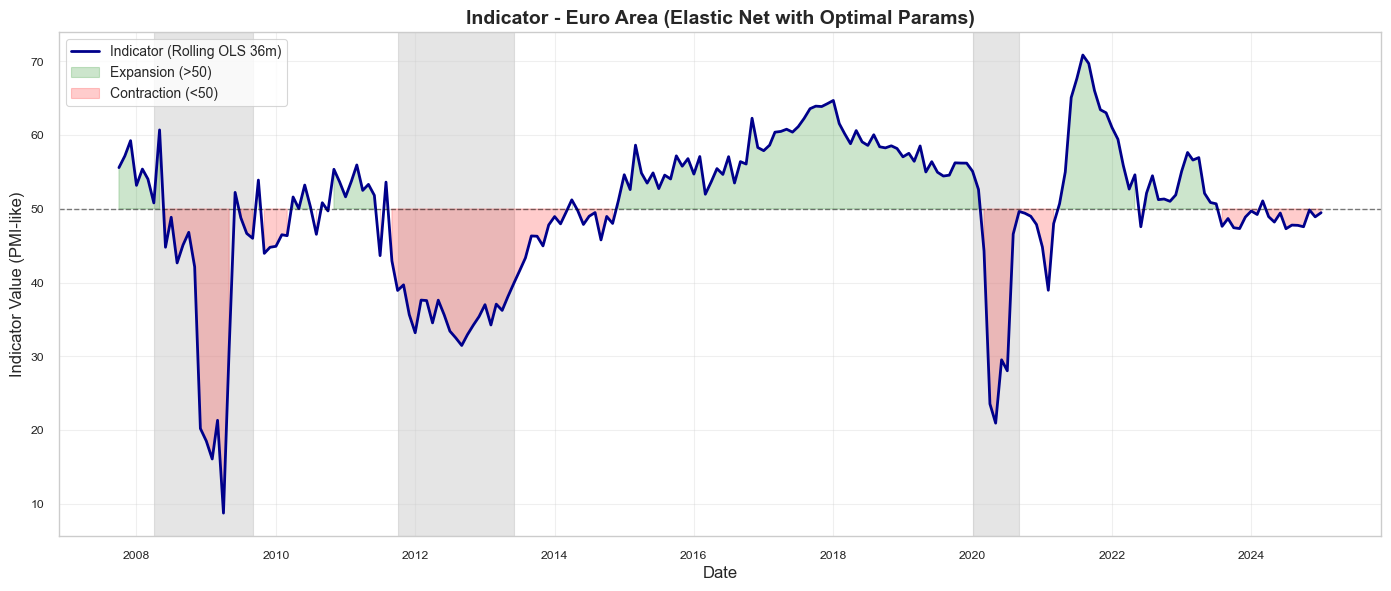

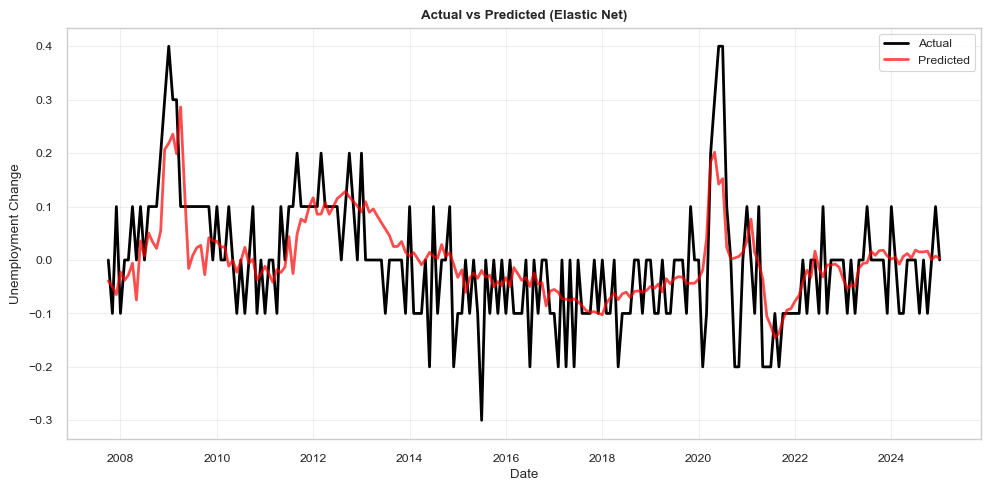

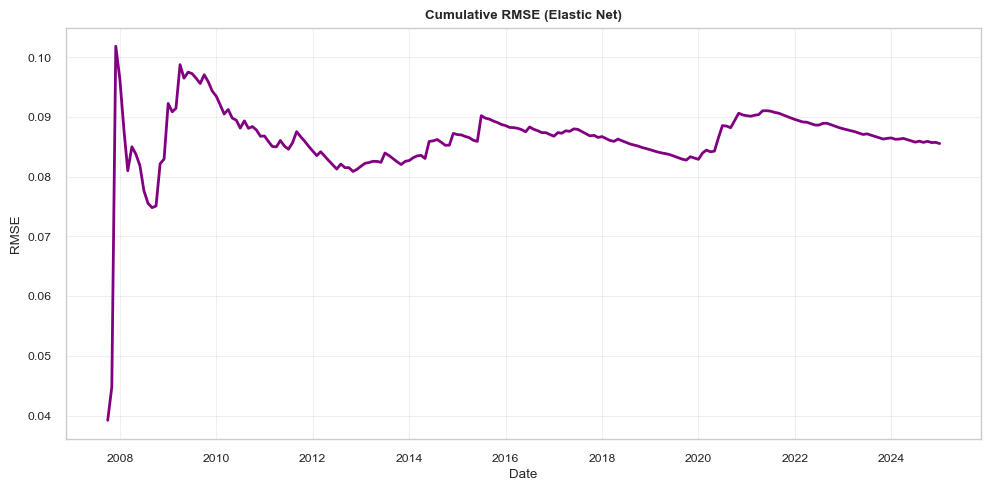

In [30]:
print("\n" + "=" * 70)
print("ECONOMIC INDICATOR - ELASTIC NET (Rolling with Optimal Params)")
print("=" * 70)

# =============================================================================
# 1/ FIT ELASTIC NET WITH OPTIMAL PARAMETERS
# =============================================================================

# Optimal parameters from CV
alpha_en = 0.05
l1_ratio_en = 0.3
n_lags_en = 6

print(f"\nUsing optimal parameters:")
print(f"  alpha = {alpha_en:.4f}")
print(f"  l1_ratio = {l1_ratio_en:.2f}")
print(f"  n_lags = {n_lags_en}")

en_model = RollingElasticNet(
    alpha=alpha_en,
    l1_ratio=l1_ratio_en,
    n_lags=n_lags_en,
    window=36,
    window_type='expanding',
    imputation_method='em',
    n_factors_imputation=10,
    rmse_window=None,
    store_coefs=True,  
    verbose=False
)

result_en = en_model.fit(y=y, X=X)

# =============================================================================
# 2/ EXTRACT INDICATOR 
# =============================================================================


indicator_raw = result_en.y_pred

# Align with actual unemployment
y_aligned = result_en.y_true


# =============================================================================
# 3/ SCALE TO PMI-LIKE 
# =============================================================================

df_indicator = indicator_pmi(raw_indic=-indicator_raw, y_aligned=y_aligned)

# =============================================================================
# 4/ VISUALIZATION
# =============================================================================

print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

plot_index(
    df_indicator=df_indicator,
    window=36,
    starts=starts,
    ends=ends,
    title="Indicator - Euro Area (Elastic Net with Optimal Params)"
)

plt.figure(figsize=(10, 5))

plt.plot(
    result_en.y_true.index, 
    result_en.y_true.values, 
    label="Actual", 
    color="black", 
    linewidth=2
)
plt.plot(
    result_en.y_pred.index, 
    result_en.y_pred.values, 
    label="Predicted", 
    color="red", 
    linewidth=2, 
    alpha=0.7
)

plt.title("Actual vs Predicted (Elastic Net)", fontweight="bold")
plt.ylabel("Unemployment Change")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("images/actual_vs_predicted_elasticnet.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(
    result_en.rmse_cum.index, 
    result_en.rmse_cum.values,
    color="purple",
    linewidth=2
)

plt.title("Cumulative RMSE (Elastic Net)", fontweight="bold")
plt.ylabel("RMSE")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("images/cumulative_rmse_elasticnet.png", dpi=300)
plt.show()

In [35]:
class TargetRandomForest:
    """
    Random Forest on a rolling or expanding window with EM imputation
    Two-step approach: Lasso selection + RF on selected variables
    """
    
    def __init__(
        self,
        window: int = 36,
        window_type: str = "expanding",
        alpha: float = 0.01,
        n_lags: int = 0,
        n_estimators: int = 100,
        criterion: Literal["squared_error", "absolute_error", "friedman_mse", "poisson"] = "squared_error",
        max_depth: int = None,
        min_samples_split: int = 2,
        min_samples_leaf: int = 1,
        imputation_method: Literal['em', 'median', 'forward_fill', 'none'] = 'em',
        n_factors_imputation: int = 10,
        max_iter_em: int = 50,
        max_iter: int = 1000,
        rmse_window: Optional[int] = 12,
        store_coefs: bool = False,
        verbose: bool = False,
    ) -> None:
        self.window = window
        self.window_type = window_type
        self.alpha = alpha
        self.n_lags = n_lags
        self.n_estimators = n_estimators
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.imputation_method = imputation_method
        self.n_factors_imputation = n_factors_imputation
        self.max_iter_em = max_iter_em
        self.max_iter = max_iter
        self.rmse_window = rmse_window
        self.store_coefs = store_coefs
        self.verbose = verbose
        self.result_: Optional[RollingResult] = None
        
    def _has_missing(self, X: pd.DataFrame) -> bool:
        return X.isna().any().any()
    
    def _impute_median(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.fillna(X.median())
    
    def _impute_forward_fill(self, X: pd.DataFrame) -> pd.DataFrame:
        X_filled = X.ffill()
        return X_filled.fillna(X_filled.median())
    
    def _impute_em(self, X: pd.DataFrame) -> Tuple[pd.DataFrame, object]:
        empca = EM_PCA(
            kmax=self.n_factors_imputation,
            criterion='IC2',
            demean=2,
            max_iter=self.max_iter_em,
            verbose=False,
            fallback_n_factors=min(3, self.n_factors_imputation)
        )
        result = empca.fit(X)
        return result.imputed_data, empca
    
    def _impute_data(
        self, 
        X_train: pd.DataFrame, 
        X_test: Optional[pd.DataFrame] = None
    ) -> Tuple[pd.DataFrame, Optional[pd.DataFrame]]:
        has_missing_train = self._has_missing(X_train)
        has_missing_test = X_test is not None and self._has_missing(X_test)
        
        if self.imputation_method == 'none':
            if has_missing_train or has_missing_test:
                raise ValueError("Missing values detected but imputation_method='none'")
            return X_train, X_test
        
        if not has_missing_train:
            X_train_imputed = X_train.copy()
            empca_model = None
        else:
            if self.imputation_method == 'em':
                X_train_imputed, empca_model = self._impute_em(X_train)
            elif self.imputation_method == 'median':
                X_train_imputed = self._impute_median(X_train)
                empca_model = None
            elif self.imputation_method == 'forward_fill':
                X_train_imputed = self._impute_forward_fill(X_train)
                empca_model = None
        
        if X_test is None or not has_missing_test:
            X_test_imputed = X_test
        else:
            if self.imputation_method == 'em' and empca_model is not None:
                _, X_test_imp = empca_model.transform(X_test, em=True, return_imputed=True)
                X_test_imputed = X_test_imp
            elif self.imputation_method == 'median':
                X_test_imputed = X_test.fillna(X_train.median())
            elif self.imputation_method == 'forward_fill':
                X_test_imputed = X_test.ffill()
                X_test_imputed = X_test_imputed.fillna(X_train.median())
        
        return X_train_imputed, X_test_imputed
    
    def fit(self, y: pd.Series, X: pd.DataFrame, threshold: float = 1e-6) -> RollingResult:
        """
        Run RF with Lasso pre-selection on a rolling or expanding window basis
        Lags are handled INSIDE the loop like BaseRollingRegressor
        """
        if len(y) != len(X):
            raise ValueError(f"y and X must have same length: {len(y)} != {len(X)}")
        if self.window >= len(y):
            raise ValueError(f"window ({self.window}) must be < data length ({len(y)})")
    
        if self.window_type not in ["rolling", "expanding"]:
            raise ValueError(f"window_type must be 'rolling' or 'expanding', got {self.window_type}")
    
        # NO lags applied here - keep full data
        df = pd.concat([y.rename("y"), X], axis=1).dropna(subset=['y'])
        y_al = df["y"]
        X_al = df.drop(columns=["y"])
        T = len(df)
    
        y_pred_list = []
        y_true_list = []
        dates_list = []
        has_missing_list = []
        n_nonzero_list = []
        feature_importance_list = [] if self.store_coefs else None
    
        # Store column names for later (will be consistent across all iterations)
        final_col_names = None
    
        for t in range(self.window, T):
            if self.verbose and t % 12 == 0:
                print(f"Processing t={t}/{T} ({y_al.index[t].strftime('%Y-%m')})")
        
            if self.window_type == "rolling":
                X_train = X_al.iloc[t - self.window : t]
                y_train = y_al.iloc[t - self.window : t]
            else:
                X_train = X_al.iloc[0 : t]
                y_train = y_al.iloc[0 : t]

            X_test = X_al.iloc[[t]]
            y_test = y_al.iloc[t]
        
            has_missing = self._has_missing(X_train) or self._has_missing(X_test)
            has_missing_list.append(has_missing)
        
            try:
                X_train_imputed, X_test_imputed = self._impute_data(X_train, X_test)
            except Exception as e:
                if self.verbose:
                    print(f"  WARNING: Imputation failed at t={t}: {e}")
                continue
        
            common_idx = y_train.index.intersection(X_train_imputed.index)
            y_train_al = y_train.loc[common_idx]
            X_train_al = X_train_imputed.loc[common_idx]
        
            if len(y_train_al) < 10:
                if self.verbose:
                    print(f"  WARNING: Only {len(y_train_al)} observations at t={t}, skipping")
                continue
        
        
            if self.n_lags > 0:
                # Combine train and test for lag creation
                X_all = pd.concat([X_train_al, X_test_imputed], axis=0)
                X_all_lag = create_lagged_dataframe(X_all, n_lags=self.n_lags, drop_na=False)
            
                # Store column names on first iteration
                if final_col_names is None:
                    final_col_names = X_all_lag.columns
            
                # Split back into train and test
                X_train_lag = X_all_lag.iloc[:-1].copy()
                X_test_lag = X_all_lag.iloc[[-1]].copy()
            
                # Remove rows with NaN from lags in train
                valid_train_idx = X_train_lag.dropna().index
                X_train_al = X_train_lag.loc[valid_train_idx]
                y_train_al = y_train_al.loc[valid_train_idx]
            
                # For test, forward fill NaN if any (use last known values)
                X_test_imputed = X_test_lag.ffill().bfill()
            else:
                # No lags - store column names on first iteration
                if final_col_names is None:
                    final_col_names = X_train_al.columns
        
            # Check again after adding lags
            if len(y_train_al) < 10:
                if self.verbose:
                    print(f"  WARNING: Only {len(y_train_al)} observations after lags at t={t}, skipping")
                continue
        
            # Scaling
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_al.values)
        
            # Step 1: Lasso variable selection
            lasso = Lasso(
                alpha=self.alpha,
                fit_intercept=True,
                max_iter=self.max_iter,
                random_state=42
            )
            lasso.fit(X_train_scaled, y_train_al.values)
        
            selected = np.abs(lasso.coef_) > threshold
            n_selected = selected.sum()
            n_nonzero_list.append(n_selected)
        
            if n_selected == 0:
                if self.verbose:
                    print(f"  WARNING: No variables selected at t={t}")
                # Still append zeros for feature importances
                if self.store_coefs:
                    importances = np.zeros(len(final_col_names))
                    importance_dict = dict(zip(final_col_names, importances))
                    feature_importance_list.append(importance_dict)
                continue
        
            X_train_selected = X_train_scaled[:, selected]
        
            # Step 2: Random Forest on selected variables
            rf = RandomForestRegressor(
                n_estimators=self.n_estimators,
                criterion=self.criterion,
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                random_state=42,
                n_jobs=-1
            )
            rf.fit(X_train_selected, y_train_al.values)
        
            # Prediction
            X_test_scaled = scaler.transform(X_test_imputed.values)
            X_test_selected = X_test_scaled[:, selected]
            y_pred = rf.predict(X_test_selected)[0]
        
            dates_list.append(y_al.index[t])
            y_true_list.append(y_test)
            y_pred_list.append(y_pred)
        
            # Store feature importances (using consistent column names)
            if self.store_coefs:
                importances = np.zeros(len(final_col_names))
                importances[selected] = rf.feature_importances_
                importance_dict = dict(zip(final_col_names, importances))
                feature_importance_list.append(importance_dict)
    
        dates_idx = pd.DatetimeIndex(dates_list)
        y_true = pd.Series(y_true_list, index=dates_idx, name="y_true")
        y_pred = pd.Series(y_pred_list, index=dates_idx, name="y_pred")
        err = y_true - y_pred
        err.name = "error"
    
        rmse_cum = np.sqrt((err ** 2).expanding().mean())
        rmse_cum.name = "rmse_cum"
    
        rmse_roll = None
        if self.rmse_window is not None and self.rmse_window >= 2:
            rmse_roll = np.sqrt((err ** 2).rolling(self.rmse_window).mean())
            rmse_roll.name = f"rmse_roll_{self.rmse_window}"
    
        has_missing_series = pd.Series(has_missing_list, index=dates_idx, name="has_missing")
        n_nonzero_series = pd.Series(n_nonzero_list, index=dates_idx, name="n_nonzero_coefs")
    
        feature_importance_df = None
        if self.store_coefs:
            feature_importance_df = pd.DataFrame(feature_importance_list, index=dates_idx)
    
        self.result_ = RollingResult(
            dates=dates_idx,
            y_true=y_true,
            y_pred=y_pred,
            err=err,
            rmse_cum=rmse_cum,
            rmse_roll=rmse_roll,
            coefficients=feature_importance_df,
            has_missing_by_window=has_missing_series,
            n_nonzero_coefs=n_nonzero_series
        )
    
        if self.verbose:
            self._print_summary()
    
        return self.result_
        
    def _print_summary(self):
        res = self.result_
        print(f"\n{'='*70}")
        print(f"ROLLING RANDOM FOREST - SUMMARY")
        print(f"{'='*70}")
        print(f"Window size          : {self.window}")
        print(f"Window type          : {self.window_type}")
        print(f"N lags               : {self.n_lags}")
        print(f"Alpha (Lasso select) : {self.alpha}")
        print(f"N estimators (RF)    : {self.n_estimators}")
        print(f"Max depth            : {self.max_depth}")
        print(f"Imputation method    : {self.imputation_method}")
        print(f"N° of predictions    : {len(res.dates)}")
        print(f"\nVariable selection:")
        print(f"  Mean #vars selected: {res.n_nonzero_coefs.mean():.1f}")
        print(f"  Min #vars selected : {res.n_nonzero_coefs.min():.0f}")
        print(f"  Max #vars selected : {res.n_nonzero_coefs.max():.0f}")
        print(f"\nMissing data:")
        pct_missing = 100 * res.has_missing_by_window.sum() / len(res.has_missing_by_window)
        print(f"  Windows with missing: {pct_missing:.1f}%")
        print(f"\nPerformance (out-of-sample):")
        print(f"  Final RMSE (cum)   : {res.rmse_cum.iloc[-1]:.4f}")
        print(f"  Mean absolute error: {res.err.abs().mean():.4f}")
        print(f"  Std of errors      : {res.err.std():.4f}")
        print(f"{'='*70}\n")
    
    def predict(self) -> pd.Series:
        if self.result_ is None:
            raise ValueError("Must call fit() before predict()")
        return self.result_.y_pred 


RANDOM FOREST - HYPERPARAMETER TUNING

Train+Valid:  195 obs (2004-10 to 2020-12)
Test:          49 obs (2021-01 to 2025-01)
Cross-validation: 5 splits on Train+Valid set

TUNING RANDOM FOREST
Parameter grid: {'alpha': [0.01, 0.05], 'n_lags': [3, 6], 'n_estimators': [50, 100], 'max_depth': [5, 10]}
Testing 16 parameter combinations...
  [1/16] Testing {'alpha': 0.01, 'n_lags': 3, 'n_estimators': 50, 'max_depth': 5}...
      -> CV RMSE: 0.0944 ± 0.0056
  [2/16] Testing {'alpha': 0.01, 'n_lags': 3, 'n_estimators': 50, 'max_depth': 10}...
      -> CV RMSE: 0.0945 ± 0.0055
  [3/16] Testing {'alpha': 0.01, 'n_lags': 3, 'n_estimators': 100, 'max_depth': 5}...
      -> CV RMSE: 0.0935 ± 0.0053
  [4/16] Testing {'alpha': 0.01, 'n_lags': 3, 'n_estimators': 100, 'max_depth': 10}...
      -> CV RMSE: 0.0936 ± 0.0053
  [5/16] Testing {'alpha': 0.01, 'n_lags': 6, 'n_estimators': 50, 'max_depth': 5}...
      -> CV RMSE: 0.0894 ± 0.0032
  [6/16] Testing {'alpha': 0.01, 'n_lags': 6, 'n_estimators': 50

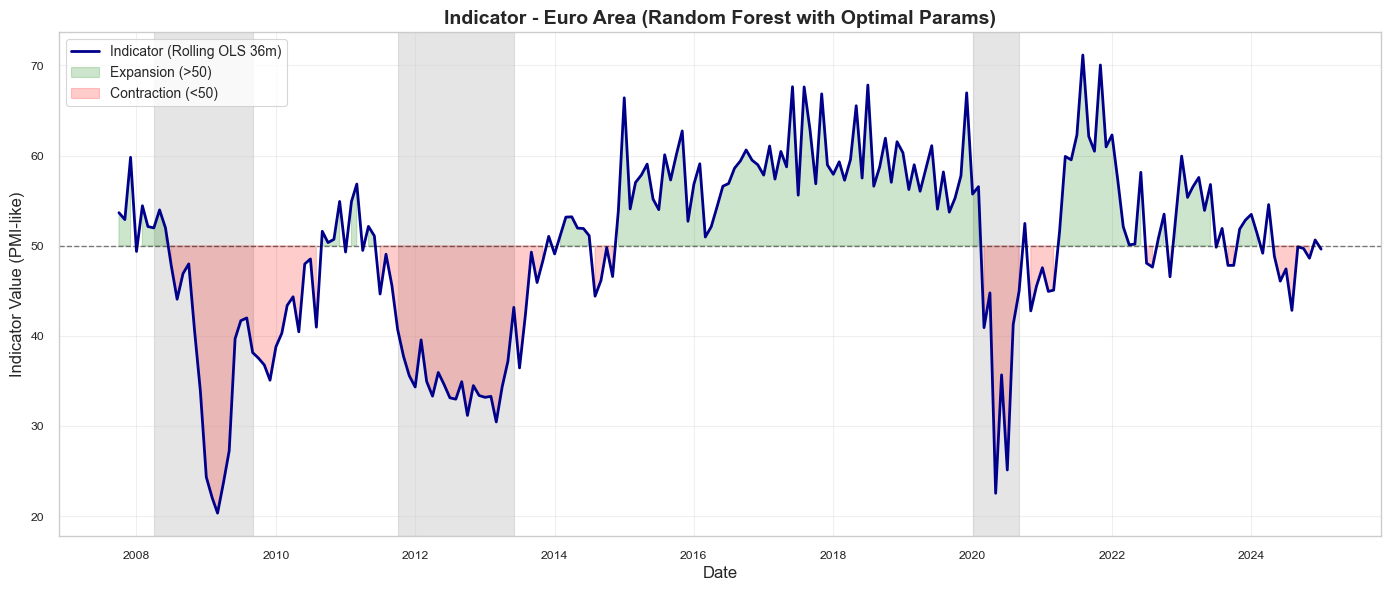


FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Variables:
CCI_EA             0.1222
SCONFIX_EA         0.1208
RTCONFIX_EA_lag1   0.0813
RTCONFIX_EA        0.0678
ICONFIX_EA         0.0633
IRT6M_EACC_lag2    0.0425
IPMN_EA_lag1       0.0376
IRT3M_EACC_lag1    0.0286
IRT6M_EACC_lag1    0.0214
TRNING_EA_lag1     0.0152
dtype: float64


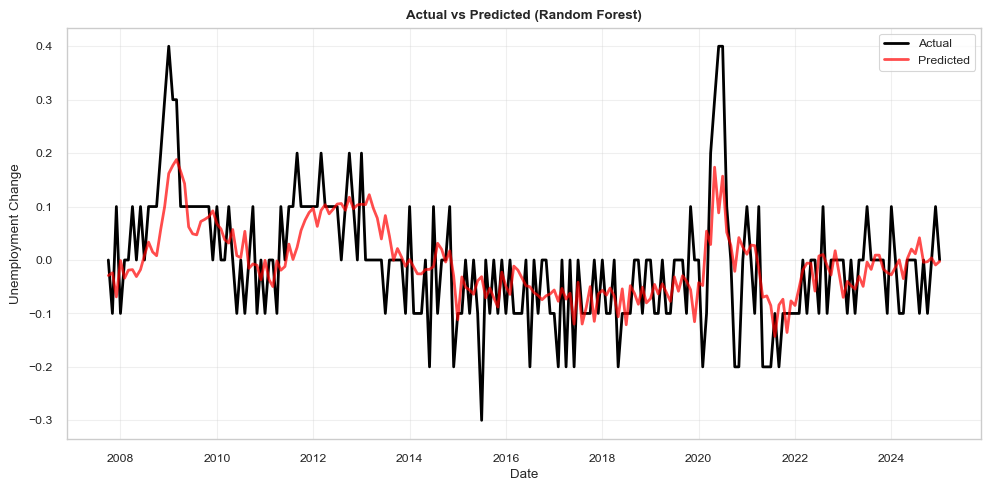

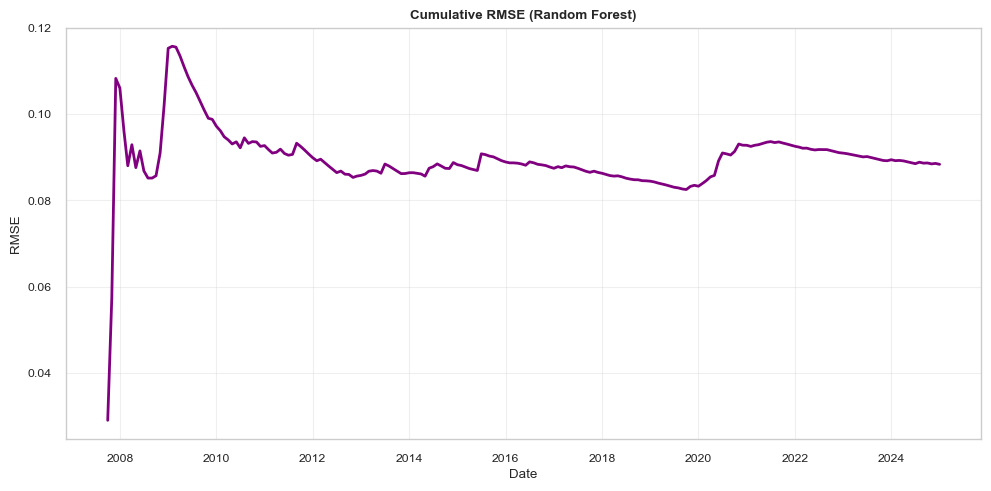

In [ ]:
print("="*70)
print("RANDOM FOREST - HYPERPARAMETER TUNING")
print("="*70)

# =============================================================================
# DATA SPLIT
# =============================================================================

split_test = int(len(X) * 0.8)
X_trainval = X.iloc[:split_test]
y_trainval = y.iloc[:split_test]
X_test_final = X.iloc[split_test:]
y_test_final = y.iloc[split_test:]

print(f"\nTrain+Valid: {len(X_trainval):4d} obs ({X_trainval.index[0].strftime('%Y-%m')} to {X_trainval.index[-1].strftime('%Y-%m')})")
print(f"Test:        {len(X_test_final):4d} obs ({X_test_final.index[0].strftime('%Y-%m')} to {X_test_final.index[-1].strftime('%Y-%m')})")

# =============================================================================
# CV SETUP
# =============================================================================

cv = TimeSeriesSplit(n_splits=5)
print(f"Cross-validation: {cv.n_splits} splits on Train+Valid set")

WINDOW = 36
WINDOW_TYPE = 'expanding'
N_FACTORS_IMP = 10

common_params = {
    'window': WINDOW,
    'window_type': WINDOW_TYPE,
    'imputation_method': 'em',
    'n_factors_imputation': N_FACTORS_IMP,
    'rmse_window': None,
    'store_coefs': False,
    'verbose': False
}

# =============================================================================
# TUNING FUNCTION
# =============================================================================

def tune_rf(param_grid):
    print(f"\n{'='*70}")
    print(f"TUNING RANDOM FOREST")
    print(f"{'='*70}")
    print(f"Parameter grid: {param_grid}")
    
    results = []
    
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    
    total_combos = np.prod([len(v) for v in param_values])
    print(f"Testing {total_combos} parameter combinations...")
    
    combo_idx = 0
    for params in product(*param_values):
        combo_idx += 1
        param_dict = dict(zip(param_names, params))
        print(f"  [{combo_idx}/{total_combos}] Testing {param_dict}...")
        
        fold_rmses = []
        fold_maes = []
        fold_nvars = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_trainval)):
            X_train_cv = X_trainval.iloc[train_idx]
            y_train_cv = y_trainval.iloc[train_idx]
            
            model = TargetRandomForest(**param_dict, **common_params)
            
            try:
                result = model.fit(y=y_train_cv, X=X_train_cv)
                
                fold_rmse = result.rmse_cum.iloc[-1]
                fold_mae = result.err.abs().mean()
                fold_nvar = result.n_nonzero_coefs.mean()
                
                fold_rmses.append(fold_rmse)
                fold_maes.append(fold_mae)
                fold_nvars.append(fold_nvar)
                
            except Exception as e:
                continue
        
        if fold_rmses:
            result_dict = {
                **param_dict,
                'mean_cv_rmse': np.mean(fold_rmses),
                'std_cv_rmse': np.std(fold_rmses),
                'mean_cv_mae': np.mean(fold_maes),
                'std_cv_mae': np.std(fold_maes),
                'mean_nvars': np.mean(fold_nvars),
                'std_nvars': np.std(fold_nvars)
            }
            results.append(result_dict)
            print(f"      -> CV RMSE: {result_dict['mean_cv_rmse']:.4f} ± {result_dict['std_cv_rmse']:.4f}")
    
    return pd.DataFrame(results)

# =============================================================================
# TUNE RANDOM FOREST
# =============================================================================

rf_grid = {
    'alpha': [0.01, 0.05],           # Lasso selection
    'n_lags': [3, 6],
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

results_rf = tune_rf(rf_grid)
best_rf = results_rf.loc[results_rf['mean_cv_rmse'].idxmin()]

print(f"\n{'='*70}\nBEST RANDOM FOREST\n{'='*70}")
print(f"  alpha = {best_rf['alpha']:.4f}, n_lags = {int(best_rf['n_lags'])}")
print(f"  n_estimators = {int(best_rf['n_estimators'])}, max_depth = {int(best_rf['max_depth'])}")
print(f"  CV RMSE = {best_rf['mean_cv_rmse']:.4f} ± {best_rf['std_cv_rmse']:.4f}")
print(f"  Mean #vars = {best_rf['mean_nvars']:.1f}")
print(f"\nFull Results:\n{results_rf.to_string(index=False)}")

# =============================================================================
# FINAL TEST OOS
# =============================================================================

print("\n" + "=" * 70)
print("FINAL TEST (Out-of-Sample)")
print("=" * 70)

# Extract parameters and convert types
param_dict = {k: (int(v) if k in ['n_lags', 'n_estimators', 'max_depth'] else float(v)) 
              for k, v in best_rf.items() 
              if k not in ['mean_cv_rmse', 'std_cv_rmse', 'mean_cv_mae', 'std_cv_mae', 'mean_nvars', 'std_nvars']}

# Create model with best params
rf_model = TargetRandomForest(
    **param_dict,
    window=common_params['window'],
    window_type=common_params['window_type'],
    imputation_method=common_params['imputation_method'],
    n_factors_imputation=common_params['n_factors_imputation'],
    rmse_window=common_params['rmse_window'],
    store_coefs=True,  # Enable to get feature importances
    verbose=False
)

X_full = pd.concat([X_trainval, X_test_final])
y_full = pd.concat([y_trainval, y_test_final])
result_rf = rf_model.fit(y=y_full, X=X_full)

y_pred_test = result_rf.y_pred.loc[y_test_final.index[0]:y_test_final.index[-1]]
y_true_test = result_rf.y_true.loc[y_test_final.index[0]:y_test_final.index[-1]]

rmse_test = np.sqrt(np.mean((y_true_test - y_pred_test) ** 2))
mae_test = np.mean(np.abs(y_true_test - y_pred_test))

print(f"\nRandom Forest Test RMSE: {rmse_test:.4f}")
print(f"Random Forest Test MAE:  {mae_test:.4f}")
print(f"CV RMSE:                 {best_rf['mean_cv_rmse']:.4f} ± {best_rf['std_cv_rmse']:.4f}")

# =============================================================================
# INDICATOR CONSTRUCTION
# =============================================================================

indicator_raw = result_rf.y_pred
y_aligned = result_rf.y_true

df_indicator_rf = indicator_pmi(raw_indic=-indicator_raw, y_aligned=y_aligned)

plot_index(
    df_indicator=df_indicator_rf,
    window=36,
    starts=starts,
    ends=ends,
    title="Indicator - Euro Area (Random Forest with Optimal Params)"
)

plt.figure(figsize=(10, 5))

plt.plot(
    result_rf.y_true.index,
    result_rf.y_true.values,
    label="Actual",
    color="black",
    linewidth=2
)
plt.plot(
    result_rf.y_pred.index,
    result_rf.y_pred.values,
    label="Predicted",
    color="red",
    linewidth=2,
    alpha=0.7
)

plt.title("Actual vs Predicted (Random Forest)", fontweight="bold")
plt.ylabel("Unemployment Change")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("images/actual_vs_predicted_rf.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(
    result_rf.rmse_cum.index,
    result_rf.rmse_cum.values,
    color="purple",
    linewidth=2
)

plt.title("Cumulative RMSE (Random Forest)", fontweight="bold")
plt.ylabel("RMSE")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("images/cumulative_rmse_rf.png", dpi=300)
plt.show()

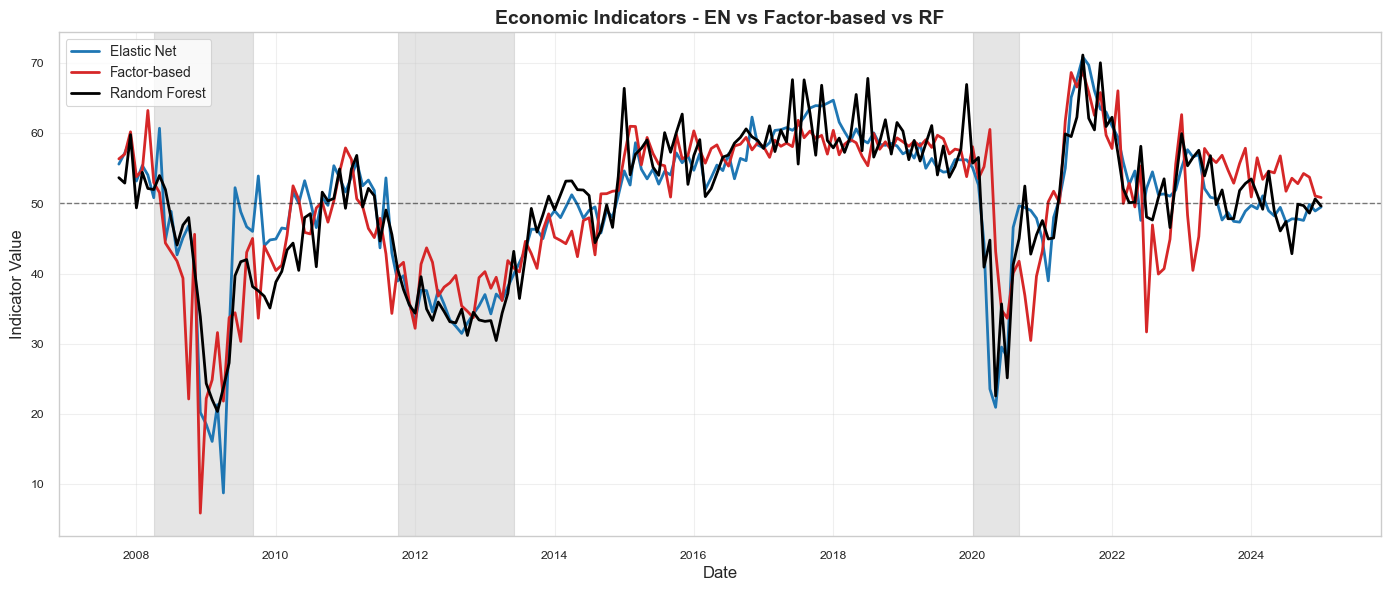

In [ ]:
def plot_three_indicators(
    window: int,
    starts,
    ends,
    df_indicator: pd.DataFrame,       # Elastic Net
    df_indicator_full: pd.DataFrame,  # PCA
    df_indicator_rf: pd.DataFrame,    # RF
    title: str = "Economic Indicators (Elastic Net vs PCA vs Random Forest)",
    normalize: bool = False,          # optional: z-score each series to compare scales
) -> None:
    """
    Plot 3 indicators on the same chart (no green/red area fill), with recession shading.
    """
    # align on a common index 
    series_en = df_indicator["Indicator"].rename("Elastic Net")
    series_pca = df_indicator_full["Indicator"].rename("PCA")
    series_rf = df_indicator_rf["Indicator"].rename("Random Forest")

    df_plot = pd.concat([series_en, series_pca, series_rf], axis=1).sort_index()

    # optional normalization (helps if indicators are on different scales)
    if normalize:
        df_plot = (df_plot - df_plot.mean()) / df_plot.std(ddof=0)

    fig, ax = plt.subplots(figsize=(14, 6))

    # 3 lines (default matplotlib colors)
    ax.plot(df_plot.index, df_plot["Elastic Net"], linewidth=2, label=f"Elastic Net")
    ax.plot(df_plot.index, df_plot["PCA"], linewidth=2, label=f"Factor-based")
    ax.plot(df_plot.index, df_plot["Random Forest"], linewidth=2, label=f"Random Forest")

    
    ax.axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.5)

    # recession shading
    for s, e in zip(starts, ends):
        ax.axvspan(s, e, color="grey", alpha=0.2, zorder=0)

    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Indicator Value" + (" (z-score)" if normalize else ""), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(loc="upper left", fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_three_indicators(
    window=window,
    starts=starts,
    ends=ends,
    df_indicator=df_indicator,            
    df_indicator_full=df_indicator_full,  
    df_indicator_rf=df_indicator_rf,      
    title="Economic Indicators - EN vs Factor-based vs RF",
    normalize=False,  
)
